# Khảo sát 4 dataset E-commerce — D.III.3 & D.IV

Notebook khảo sát các dataset ứng viên E-commerce có comments/reviews để:
- hiểu schema và chất lượng dữ liệu;
- xác định nhóm cột numerical / categorical / text;
- tìm `target` khả thi cho supervised learning;
- đánh giá mức độ phù hợp với bài toán **customer behavior / interest discovery**;
- tạo bảng tổng hợp để chọn `primary dataset`.

> **Phạm vi:** Data Inspection và đánh giá so sánh ứng viên — chưa làm cleaning chính thức, tokenization, train/test split hay training.

> **Lưu ý:** chạy notebook từ thư mục `customer_behavior/notebook` để đường dẫn `../data` trỏ đúng dữ liệu. Sau khi Run All, nhớ **Save** để giữ output.


In [1]:
# Cell này: đọc 4 file CSV của 4 dataset ứng viên vào dictionary `dfs` để khảo sát.

# pathlib: thư viện giúp làm việc với đường dẫn file/thư mục (Path).
from pathlib import Path

# pandas: thư viện đọc và xử lý dữ liệu dạng bảng (DataFrame).
import pandas as pd

# Định nghĩa đường dẫn tới thư mục data chứa các file CSV.
DATA_DIR = Path("../data")

# Ánh xạ tên dataset (data_1..data_4) tới đường dẫn file CSV tương ứng.
datasets = {
    # data_1: Amazon Product Reviews.
    "data_1": DATA_DIR / "amazon_com-product_reviews__20200101_20200331_sample.csv",
    # data_2: Customer Sentiment.
    "data_2": DATA_DIR / "Customer_Sentiment.csv",
    # data_3: Synthetic E-commerce Product Reviews.
    "data_3": DATA_DIR / "ecommerce_product_reviews_dataset.csv",
    # data_4: Women's Clothing E-Commerce Reviews.
    "data_4": DATA_DIR / "Womens Clothing E-Commerce Reviews.csv",
}

# Tên hiển thị đầy đủ của từng dataset (dùng cho tiêu đề và bảng kết quả).
DISPLAY_NAMES = {
    "data_1": "Amazon Product Reviews",
    "data_2": "Customer Sentiment",
    "data_3": "Synthetic E-commerce Product Reviews",
    "data_4": "Women's Clothing E-Commerce Reviews",
}

# Đọc toàn bộ file CSV: khoá = tên dataset, giá trị = DataFrame.
dfs = {name: pd.read_csv(path) for name, path in datasets.items()}


## 1. Hàm hỗ trợ khảo sát

Các hàm bên dưới phục vụ:
- phân nhóm cột sơ bộ: `id`, `text`, `categorical`, `numerical`;
- đánh giá text review: missing, độ dài, số từ, gợi ý ngôn ngữ;
- tìm candidate cho `target` và category/interest;
- rà soát giá trị nghi ngờ và outlier tiềm năng (IQR).

> Nhận diện cột chỉ là gợi ý ban đầu; không thay thế việc hiểu ý nghĩa thật của từng cột.


In [2]:
# Các thư viện dùng cho phần phân tích.
import re
import unicodedata
import warnings

import numpy as np
from IPython.display import display

warnings.filterwarnings("ignore")

# Hiển thị bảng rộng, không cắt nội dung cột dài.
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)


# Từ khoá gợi ý nhóm cột (đối chiếu sau khi chuẩn hoá tên cột).
TEXT_NAME_HINTS = {
    "review",
    "reviewtext",
    "reviewbody",
    "reviewcontent",
    "comment",
    "comments",
    "feedback",
    "remarks",
    "remark",
    "description",
    "text",
    "content",
    "summary",
    "title",
    "headline",
}
TARGET_NAME_HINTS = {
    "target",
    "label",
    "class",
    "category",
    "productcategory",
    "department",
    "sentiment",
    "preference",
    "interest",
    "recommended",
    "recommendation",
    "rating",
    "stars",
    "score",
    "purchase",
    "return",
}
CATEGORY_NAME_HINTS = {
    "category",
    "department",
    "division",
    "class",
    "type",
    "producttype",
    "productcategory",
    "brand",
}
ID_NAME_HINTS = {
    "id",
    "userid",
    "user_id",
    "customerid",
    "customer_id",
    "productid",
    "product_id",
    "asin",
    "sku",
    "index",
    "uniqid",
    "uniqueid",
}

# Giá trị placeholder thường gặp trong cột text.
PLACEHOLDER_VALUES = {
    "",
    "na",
    "n/a",
    "nan",
    "none",
    "null",
    "missing",
    "unknown",
    "no info",
    "not available",
    "-",
    "--",
}

# Stopword tiếng Anh / tiếng Việt dùng để gợi ý ngôn ngữ.
EN_STOPWORDS = {
    "the",
    "and",
    "is",
    "it",
    "this",
    "that",
    "was",
    "for",
    "of",
    "to",
    "in",
    "with",
    "on",
    "but",
    "not",
    "very",
    "i",
    "my",
    "a",
    "an",
    "are",
    "love",
    "like",
    "good",
    "great",
    "product",
    "review",
}
VI_STOPWORDS = {
    "và",
    "là",
    "của",
    "cho",
    "tôi",
    "mình",
    "rất",
    "không",
    "có",
    "này",
    "được",
    "với",
    "một",
    "nhưng",
    "sản",
    "phẩm",
    "tốt",
    "thích",
    "đẹp",
    "mua",
    "hàng",
    "giao",
}


# Chuẩn hoá tên: bỏ dấu, bỏ ký tự đặc biệt, viết thường (không dấu cách).
def normalize_name(value) -> str:
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"[^a-z0-9]+", "", text.lower())


# Kiểm tra cột có dạng id (tên chứa id/asin/sku hoặc bắt đầu/kết thúc bằng id).
def is_id_like(col: str) -> bool:
    n = normalize_name(col)
    id_hints = {normalize_name(x) for x in ID_NAME_HINTS}
    return n in id_hints or n.startswith("id") or n.endswith("id") or "asin" in n or "sku" in n


# Thống kê nhanh cột text: cỡ mẫu, độ dài, số từ và tỷ lệ unique.
def text_profile(series: pd.Series, sample_size: int = 3000) -> dict:
    s = series.dropna().astype(str).str.strip()
    s = s[s.ne("")]

    if len(s) > sample_size:
        # Lấy mẫu cố định (random_state) để kết quả tái lập được.
        s = s.sample(sample_size, random_state=42)

    if s.empty:
        return {
            "non_null_sample": 0,
            "avg_chars": 0.0,
            "median_chars": 0.0,
            "avg_words": 0.0,
            "unique_ratio": 0.0,
        }

    char_len = s.str.len()
    return {
        "non_null_sample": len(s),
        "avg_chars": float(char_len.mean()),
        "median_chars": float(char_len.median()),
        "avg_words": float(s.str.split().str.len().mean()),
        "unique_ratio": float(s.nunique() / len(s)),
    }


# Gợi ý ngôn ngữ English/Vietnamese dựa trên số stopword xuất hiện trong mẫu.
def language_hint(series: pd.Series, sample_size: int = 300) -> str:
    s = series.dropna().astype(str).str.strip()
    s = s[s.ne("")]

    if s.empty:
        return "Không xác định"

    if len(s) > sample_size:
        s = s.sample(sample_size, random_state=42)

    tokens = re.findall(r"[a-zA-ZÀ-ỹ]+", " ".join(s.tolist()).lower())
    en = sum(token in EN_STOPWORDS for token in tokens)
    vi = sum(token in VI_STOPWORDS for token in tokens)

    if en >= max(8, vi * 1.5):
        return "English-like"
    if vi >= max(8, en * 1.5):
        return "Vietnamese-like"
    return "Không xác định rõ"


# Phân nhóm cột sơ bộ: id, text, categorical, numerical.
def identify_semantic_columns(df: pd.DataFrame) -> dict:
    groups = {"text": [], "id": [], "categorical": [], "numerical": []}

    for col in df.columns:
        s = df[col]
        n = normalize_name(col)

        if is_id_like(col):
            groups["id"].append(col)
        elif pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
            prof = text_profile(s)
            explicit_text_name = any(hint in n for hint in TEXT_NAME_HINTS)
            looks_free_text = prof["median_chars"] >= 30 and prof["unique_ratio"] >= 0.20

            # Ưu tiên cột có tên gợi ý text; nếu không, dùng heuristic text dài.
            if explicit_text_name and prof["median_chars"] >= 15:
                groups["text"].append(col)
            elif looks_free_text:
                groups["text"].append(col)
            else:
                groups["categorical"].append(col)
        elif pd.api.types.is_bool_dtype(s) or pd.api.types.is_categorical_dtype(s):
            groups["categorical"].append(col)
        elif pd.api.types.is_numeric_dtype(s):
            # Cột số cardinality thấp thường là category/label đã mã hoá.
            low_cardinality = s.nunique(dropna=True) <= 20 and not any(
                k in n for k in ["age", "price", "amount", "count", "length"]
            )
            groups["categorical" if low_cardinality else "numerical"].append(col)

    return groups


# Liệt kê cột có tên gợi ý category/department/class/brand.
def detect_category_candidates(df: pd.DataFrame) -> list:
    rows = []
    for col in df.columns:
        n = normalize_name(col)
        if any(hint in n for hint in CATEGORY_NAME_HINTS):
            rows.append(
                {
                    "column": col,
                    "dtype": str(df[col].dtype),
                    "nunique": int(df[col].nunique(dropna=True)),
                    "missing_percent": round(float(df[col].isna().mean() * 100), 2),
                }
            )
    return rows


# Tìm cột khả thi làm target: tên gợi ý kết hợp cardinality thấp/vừa.
def detect_target_candidates(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for col in df.columns:
        s = df[col]
        n = normalize_name(col)
        nunique = int(s.nunique(dropna=True))
        missing_pct = float(s.isna().mean() * 100)
        name_score = sum(1 for hint in TARGET_NAME_HINTS if hint in n)

        low_cardinality = 2 <= nunique <= 50
        medium_category = 2 <= nunique <= 150 and any(
            k in n for k in ["category", "department", "class", "type"]
        )

        if name_score > 0 and (low_cardinality or medium_category):
            rows.append(
                {
                    "column": col,
                    "dtype": str(s.dtype),
                    "nunique": nunique,
                    "missing_percent": round(missing_pct, 2),
                    "name_score": name_score,
                }
            )

    columns = ["column", "dtype", "nunique", "missing_percent", "name_score"]
    if not rows:
        return pd.DataFrame(columns=columns)
    return (
        pd.DataFrame(rows)
        .sort_values(["name_score", "nunique", "missing_percent"], ascending=[False, True, True])
        .reset_index(drop=True)
    )


# Ước lượng outlier cột số bằng quy tắc 1.5 * IQR.
def iqr_outlier_summary(df: pd.DataFrame) -> pd.DataFrame:
    columns = ["column", "min", "max", "IQR_lower", "IQR_upper", "potential_outliers", "percent"]
    rows = []

    for col in df.select_dtypes(include="number").columns:
        if is_id_like(col):
            continue

        s = df[col].dropna()
        if s.empty or s.nunique() < 8:
            continue

        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue

        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = int(((s < lower) | (s > upper)).sum())
        rows.append(
            {
                "column": col,
                "min": s.min(),
                "max": s.max(),
                "IQR_lower": lower,
                "IQR_upper": upper,
                "potential_outliers": count,
                "percent": round(count / len(s) * 100, 2),
            }
        )

    if not rows:
        return pd.DataFrame(columns=columns)
    return (
        pd.DataFrame(rows).sort_values("potential_outliers", ascending=False).reset_index(drop=True)
    )


# Rà soát giá trị nghi ngờ: chuỗi rỗng/placeholder, giá trị vô cực, phạm vi rating.
def suspicious_value_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    # 1) Chuỗi rỗng hoặc giá trị placeholder trong cột text.
    for col in df.select_dtypes(include=["object", "string"]).columns:
        stripped = df[col].astype("string").str.strip().str.lower()
        blank = int(stripped.eq("").sum())
        placeholder = int(stripped.isin(PLACEHOLDER_VALUES).sum())
        if blank or placeholder:
            rows.append(
                {
                    "column": col,
                    "issue": "blank/placeholder string",
                    "count": blank + placeholder,
                    "details": f"blank={blank}, placeholder={placeholder}",
                }
            )

    # 2) Giá trị vô cực trong cột số.
    for col in df.select_dtypes(include="number").columns:
        inf_count = int(np.isinf(df[col].to_numpy(dtype=float, na_value=np.nan)).sum())
        if inf_count:
            rows.append(
                {"column": col, "issue": "infinite value", "count": inf_count, "details": ""}
            )

    # 3) Kiểm tra phạm vi hợp lý của cột rating/star/score.
    for col in df.select_dtypes(include="number").columns:
        n = normalize_name(col)
        if any(k in n for k in ["rating", "star", "score"]):
            s = df[col].dropna()
            if not s.empty:
                rows.append(
                    {
                        "column": col,
                        "issue": "rating/score range audit",
                        "count": len(s),
                        "details": f"min={s.min()}, max={s.max()}, nunique={s.nunique()}",
                    }
                )

    return pd.DataFrame(rows)


## 2. Khảo sát từng dataset

Với mỗi dataset, hiển thị `shape`, `head`, `info`, `describe(include="all")`, missing, duplicate, nhóm cột semantic, target/category candidates, suspicious values và outlier tiềm năng (IQR).


In [3]:
inspection_results = {}

for key, df in dfs.items():
    name = DISPLAY_NAMES[key]
    print(f"\n===== DATASET: {name} ({key}) | shape: {df.shape} =====")

    print("\nhead():")
    display(df.head(5))

    print("\ninfo():")
    df.info()

    print("\ndescribe(include='all'):")
    display(df.describe(include="all").T)

    print("\nMissing:")
    missing = df.isna().sum()
    display(
        pd.DataFrame(
            {
                "missing_count": missing,
                "missing_percent": (missing / len(df) * 100).round(2),
            }
        ).sort_values("missing_count", ascending=False)
    )

    dup_count = int(df.duplicated().sum())
    dup_rate = dup_count / len(df) * 100 if len(df) else 0
    print(f"\nDuplicates: {dup_count} ({dup_rate:.4f}%)")

    semantic = identify_semantic_columns(df)
    targets = detect_target_candidates(df)
    categories = detect_category_candidates(df)
    outliers = iqr_outlier_summary(df)
    suspicious = suspicious_value_summary(df)

    print("\nSemantic column groups:")
    for group, cols in semantic.items():
        print(f"- {group}: {cols}")

    print("\nTarget candidates:")
    display(targets)

    print("\nCategory/interest candidates:")
    display(pd.DataFrame(categories))

    print("\nSuspicious values:")
    display(suspicious)

    print("\nPotential outliers (IQR):")
    display(outliers.head(20))

    inspection_results[key] = {
        "semantic": semantic,
        "targets": targets,
        "categories": categories,
        "outliers": outliers,
        "suspicious": suspicious,
        "duplicate_count": dup_count,
        "duplicate_rate": dup_rate,
    }



===== DATASET: Amazon Product Reviews (data_1) | shape: (50, 18) =====

head():


,Uniq Id,Crawl Timestamp,Billing Uniq Id,Rating,Review Title,Review Rating,Review Date,User Id,Brand,Category,Sub Category,Product Description,Asin,Url,Review Content,Verified Purchase,Helpful Review Count,Manufacturer Response
0,10d8b81dc693db8a3f92e19254525d53,2020-03-17 02:32:10 +0000,c697dc43961526785292107b91a639e1,NaN,Best Natural Deodorant!!,5.0,"March 6, 2020",AGIZFDSHLSBZ7KHQ4FV65W7B3HMQ,Schmidt's Deodorant,Beauty & Personal Care,Personal Care,Schmidt’s natural deodorant formulas use innovative ingredients derived from plants and minerals to help effectively neutralize odor and...,B071YYMZ19,https://www.amazon.com/gp/customer-reviews/R2QDG3B3GJO8W/ref=cm_cr_arp_d_rvw_ttl?ie=UTF8&ASIN=B071YYMZ19,"This is the one natural deodorant that works for me, no b.o smell throughout the day! Score. Although it will never absorb quite like th...",Verified Purchase,0,NaN
1,31ef1ee4961d3fcff33e363edd7677eb,2020-03-17 02:32:10 +0000,c697dc43961526785292107b91a639e1,NaN,Schmidt's Charcoal Deodorant is the best!,5.0,"March 6, 2020",AHOZPYWO6WE5MLAZZPDUAWNKKNRQ,Schmidt's Deodorant,Beauty & Personal Care,Personal Care,Schmidt’s natural deodorant formulas use innovative ingredients derived from plants and minerals to help effectively neutralize odor and...,B071YYMZ19,https://www.amazon.com/gp/customer-reviews/R14AFY08Z2YN9S/ref=cm_cr_arp_d_rvw_ttl?ie=UTF8&ASIN=B071YYMZ19,I am staying away from the conventional deodorants that have lots of fragrance combined with aluminum which is an irritant to my skin an...,Verified Purchase,0,NaN
2,6943e517922b051cbec496be32fbb57f,2020-03-17 02:32:10 +0000,c697dc43961526785292107b91a639e1,NaN,Beware. Defective or counterfeit.,1.0,"March 6, 2020",AECC6GYWWLNCKSBG3DZDGFSYDOTA,Schmidt's Deodorant,Beauty & Personal Care,Personal Care,Schmidt’s natural deodorant formulas use innovative ingredients derived from plants and minerals to help effectively neutralize odor and...,B071YYMZ19,https://www.amazon.com/gp/customer-reviews/R2RSQCFKI17X4L/ref=cm_cr_arp_d_rvw_ttl?ie=UTF8&ASIN=B071YYMZ19,"Do not buy this from Amazon it's either defective or counterfeit. I used to buy the same product at Costco, it works great. As the pictu...",Verified Purchase,One person found this helpful Helpful,NaN
3,6778c794e6ac7112981d4ebb239d6826,2020-03-17 02:32:10 +0000,c697dc43961526785292107b91a639e1,NaN,Good for infrequent shavers in cooler months in unimportant clothes,3.0,"March 5, 2020",AEOO6OOEO4QD7Z4F6C2FMZUCW7PA,Schmidt's Deodorant,Beauty & Personal Care,Personal Care,Schmidt’s natural deodorant formulas use innovative ingredients derived from plants and minerals to help effectively neutralize odor and...,B071YYMZ19,https://www.amazon.com/gp/customer-reviews/RMIK84HKMM45Y/ref=cm_cr_arp_d_rvw_ttl?ie=UTF8&ASIN=B071YYMZ19,I started using this because I was getting cysts from aluminum antiperspirants. After studying the properties of charcoal in an academic...,NO,0,NaN
4,2335a28ae24db3b2191080bfd98a86e0,2020-03-17 02:32:10 +0000,c697dc43961526785292107b91a639e1,NaN,This isn’t the true product and will hurt your armpits!,1.0,"March 2, 2020",AEHSDCGRIMVOUG6ST35FJ4FMMW5Q,Schmidt's Deodorant,Beauty & Personal Care,Personal Care,Schmidt’s natural deodorant formulas use innovative ingredients derived from plants and minerals to help effectively neutralize odor and...,B071YYMZ19,https://www.amazon.com/gp/customer-reviews/R1R8R5EBNBQPHI/ref=cm_cr_arp_d_rvw_ttl?ie=UTF8&ASIN=B071YYMZ19,Dont buy this from amazon!!!! I never write reviews but felt others should know this. I’ve been using this deodorant for a while and pur...,Verified Purchase,One person found this helpful Helpful,NaN



info():
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Uniq Id                50 non-null     str    
 1   Crawl Timestamp        50 non-null     str    
 2   Billing Uniq Id        50 non-null     str    
 3   Rating                 0 non-null      float64
 4   Review Title           50 non-null     str    
 5   Review Rating          50 non-null     float64
 6   Review Date            50 non-null     str    
 7   User Id                50 non-null     str    
 8   Brand                  50 non-null     str    
 9   Category               49 non-null     str    
 10  Sub Category           49 non-null     str    
 11  Product Description    49 non-null     str    
 12  Asin                   50 non-null     str    
 13  Url                    50 non-null     str    
 14  Review Content         50 non-null     str    
 15  Verified P

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Uniq Id,50,50,10d8b81dc693db8a3f92e19254525d53,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crawl Timestamp,50,8,2020-03-17 02:32:10 +0000,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Uniq Id,50,8,c697dc43961526785292107b91a639e1,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Title,50,49,Yummy!,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Rating,50.0,NaN,NaN,NaN,4.18,1.409733,1.0,4.0,5.0,5.0,5.0
Review Date,50,36,"March 6, 2020",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User Id,50,50,AGIZFDSHLSBZ7KHQ4FV65W7B3HMQ,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,50,6,Schmidt's Deodorant,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,49,2,Beauty & Personal Care,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing:


...

,column,dtype,nunique,missing_percent
0,Division Name,str,3,0.06
1,Department Name,str,6,0.06
2,Class Name,str,20,0.06



Suspicious values:


,column,issue,count,details
0,Rating,rating/score range audit,23486,"min=1, max=5, nunique=5"



Potential outliers (IQR):


,column,min,max,IQR_lower,IQR_upper,potential_outliers,percent
0,Positive Feedback Count,0,122,-4.5,7.5,2147,9.14
1,Age,18,99,7.0,79.0,109,0.46
2,Unnamed: 0,0,23485,-11742.5,35227.5,0,0.00


## 3. Đánh giá comments / reviews

Với mỗi cột free-text phát hiện được, báo missing, độ dài trung bình/trung vị, số từ trung bình, tỷ lệ unique, gợi ý ngôn ngữ và 3 ví dụ — để chứng minh dataset thật sự có review/comment chất lượng.


In [4]:
text_readiness_rows = []

for key, df in dfs.items():
    name = DISPLAY_NAMES[key]
    text_cols = inspection_results[key]["semantic"]["text"]
    print(f"\n===== TEXT READINESS: {name} =====")

    if not text_cols:
        print("Không phát hiện cột free-text rõ ràng.")
        text_readiness_rows.append(
            {
                "Dataset": name,
                "Text available": "No",
                "Text column": None,
                "Missing (%)": None,
                "Avg words": None,
                "Median chars": None,
                "Language hint": None,
            }
        )
        continue

    for col in text_cols:
        prof = text_profile(df[col])
        lang = language_hint(df[col])
        missing_pct = float(df[col].isna().mean() * 100)

        row = {
            "Dataset": name,
            "Text available": "Yes",
            "Text column": col,
            "Missing (%)": round(missing_pct, 2),
            "Avg words": round(prof["avg_words"], 2),
            "Median chars": round(prof["median_chars"], 2),
            "Unique ratio": round(prof["unique_ratio"], 3),
            "Language hint": lang,
        }
        text_readiness_rows.append(row)

        print(f"\nText column: {col}")
        display(pd.DataFrame([row]))

        examples = df[col].dropna().astype(str).str.strip()
        examples = examples[examples.ne("")]
        print("Examples:")
        for i, value in enumerate(examples.head(3), start=1):
            preview = value.replace(chr(10), " ")
            print(f"{i}. {preview[:500]}")

text_readiness = pd.DataFrame(text_readiness_rows)
print("\n===== TỔNG HỢP TEXT READINESS =====")
display(text_readiness)



===== TEXT READINESS: Amazon Product Reviews =====

Text column: Review Title


,Dataset,Text available,Text column,Missing (%),Avg words,Median chars,Unique ratio,Language hint
0,Amazon Product Reviews,Yes,Review Title,0.0,3.86,18.5,0.98,English-like


Examples:
1. Best Natural Deodorant!!
2. Schmidt's Charcoal Deodorant is the best!
3. Beware. Defective or counterfeit.

Text column: Review Date


,Dataset,Text available,Text column,Missing (%),Avg words,Median chars,Unique ratio,Language hint
0,Amazon Product Reviews,Yes,Review Date,0.0,3.0,16.0,0.72,Không xác định rõ


Examples:
1. March 6, 2020
2. March 6, 2020
3. March 6, 2020

Text column: Product Description


...

,Dataset,Text available,Text column,Missing (%),Avg words,Median chars,Unique ratio,Language hint
0,Women's Clothing E-Commerce Reviews,Yes,Title,16.22,3.38,17.0,0.834,English-like


Examples:
1. Some major design flaws
2. My favorite buy!
3. Flattering shirt

Text column: Review Text


,Dataset,Text available,Text column,Missing (%),Avg words,Median chars,Unique ratio,Language hint
0,Women's Clothing E-Commerce Reviews,Yes,Review Text,3.6,59.49,297.0,1.0,English-like


Examples:
1. Absolutely wonderful - silky and sexy and comfortable
2. Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i bought a petite and am 5'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.
3. I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c

===== TỔNG HỢP TEXT READINESS =====


,Dataset,Text available,Text column,Missing (%),Avg words,Median chars,Unique ratio,Language hint
0,Amazon Product Reviews,Yes,Review Title,0.00,3.86,18.5,0.980,English-like
1,Amazon Product Reviews,Yes,Review Date,0.00,3.00,16.0,0.720,Không xác định rõ
2,Amazon Product Reviews,Yes,Product Description,2.00,171.35,1324.0,0.143,English-like
3,Amazon Product Reviews,Yes,Url,0.00,1.00,104.0,1.000,Không xác định rõ
4,Amazon Product Reviews,Yes,Review Content,0.00,32.82,110.0,1.000,English-like
5,Customer Sentiment,Yes,review_text,0.00,4.64,33.0,0.005,English-like
6,Synthetic E-commerce Product Reviews,Yes,product_title,0.00,2.84,19.0,0.011,English-like
7,Synthetic E-commerce Product Reviews,Yes,review_text,0.00,4.78,31.5,0.008,English-like
8,Women's Clothing E-Commerce Reviews,Yes,Title,16.22,3.38,17.0,0.834,English-like
9,Women's Clothing E-Commerce Reviews,Yes,Review Text,3.60,59.49,297.0,1.000,English-like


## 4. Phân tích target và class distribution

Chưa chốt model ở phase D, nhưng cần biết mỗi dataset hỗ trợ target nào (rating, sentiment, recommendation, category...). Với candidate có ≤ 30 class, in phân bố để đánh giá class imbalance.

> Lưu ý: `rating` dùng được làm ordinal/multiclass target nhưng không đồng nghĩa với interest; `category/department` phù hợp hơn cho product/category discovery; `sentiment/recommended` phù hợp hơn cho preference.


In [5]:
target_distribution_rows = []

for key, df in dfs.items():
    name = DISPLAY_NAMES[key]
    candidates = inspection_results[key]["targets"]
    print(f"\n===== TARGET CANDIDATES: {name} =====")

    if candidates.empty:
        print("Không phát hiện target candidate rõ ràng.")
        continue

    display(candidates)

    for _, cand in candidates.head(5).iterrows():
        col = cand["column"]
        nunique = int(cand["nunique"])
        print(f"\nCandidate: {col} | nunique={nunique}")

        if nunique > 30:
            print("Bỏ qua vì cardinality > 30.")
            continue

        dist = pd.DataFrame(
            {
                "count": df[col].value_counts(dropna=False),
                "percent": df[col].value_counts(normalize=True, dropna=False).mul(100).round(2),
            }
        )
        display(dist.head(30))

        non_missing_dist = df[col].dropna().value_counts(normalize=True).mul(100)
        dominant = float(non_missing_dist.iloc[0]) if len(non_missing_dist) else np.nan
        target_distribution_rows.append(
            {
                "Dataset": name,
                "Target candidate": col,
                "Classes": nunique,
                "Missing (%)": round(float(df[col].isna().mean() * 100), 2),
                "Largest class (%)": round(dominant, 2) if pd.notna(dominant) else None,
            }
        )

target_distribution_summary = pd.DataFrame(target_distribution_rows)
print("\n===== TỔNG HỢP TARGET / CLASS BALANCE =====")
display(target_distribution_summary)



===== TARGET CANDIDATES: Amazon Product Reviews =====


,column,dtype,nunique,missing_percent,name_score
0,Verified Purchase,str,2,0.0,1
1,Category,str,2,2.0,1
2,Sub Category,str,4,2.0,1
3,Review Rating,float64,5,0.0,1



Candidate: Verified Purchase | nunique=2


,count,percent
Verified Purchase,,
Verified Purchase,46,92.0
NO,4,8.0



Candidate: Category | nunique=2


...

,count,percent
Department Name,,
Tops,10468,44.57
Dresses,6319,26.91
Bottoms,3799,16.18
Intimate,1735,7.39
Jackets,1032,4.39
Trend,119,0.51
NaN,14,0.06



Candidate: Class Name | nunique=20


,count,percent
Class Name,,
Dresses,6319,26.91
Knits,4843,20.62
Blouses,3097,13.19
Sweaters,1428,6.08
Pants,1388,5.91
Jeans,1147,4.88
Fine gauge,1100,4.68
Skirts,945,4.02
Jackets,704,3.00



===== TỔNG HỢP TARGET / CLASS BALANCE =====


,Dataset,Target candidate,Classes,Missing (%),Largest class (%)
0,Amazon Product Reviews,Verified Purchase,2,0.00,92.00
1,Amazon Product Reviews,Category,2,2.00,73.47
2,Amazon Product Reviews,Sub Category,4,2.00,42.86
3,Amazon Product Reviews,Review Rating,5,0.00,68.00
4,Customer Sentiment,product_category,9,0.00,11.43
5,Customer Sentiment,sentiment,3,0.00,39.91
6,Customer Sentiment,customer_rating,5,0.00,20.34
7,Synthetic E-commerce Product Reviews,sentiment,3,0.00,51.59
8,Synthetic E-commerce Product Reviews,rating,5,0.00,31.97
9,Synthetic E-commerce Product Reviews,category,8,0.00,12.54


## 5. Bảng tổng hợp cho D.III.3 & D.IV

- `ecommerce_screening_summary`: bằng chứng khảo sát từng dataset cho **D.III.3** (shape, missing, duplicate, chất lượng text, target/category candidates...).
- `primary_selection_evidence`: evidence matrix cho **D.IV** — dataset phù hợp nhất cần có review text chất lượng, target liên quan interest/preference/category, data sạch và quy mô hợp lý.

Dựa trên 2 bảng này để hoàn thiện D.III.3, D.IV.1 và D.IV.2.


In [6]:
# Chọn cột text tốt nhất cho một dataset: ưu tiên nhiều từ, ít missing.
def best_text_row_for_dataset(dataset_name: str):
    subset = text_readiness[
        (text_readiness["Dataset"] == dataset_name) & (text_readiness["Text available"] == "Yes")
    ].copy()
    if subset.empty:
        return None

    subset["rank_score"] = subset["Avg words"].fillna(0) - subset["Missing (%)"].fillna(100) * 0.1
    return subset.sort_values("rank_score", ascending=False).iloc[0]


summary_rows = []

for key, df in dfs.items():
    name = DISPLAY_NAMES[key]
    result = inspection_results[key]
    best_text = best_text_row_for_dataset(name)

    total_cells = df.shape[0] * df.shape[1]
    missing_pct = df.isna().sum().sum() / total_cells * 100 if total_cells else 0

    suspicious_cols = (
        result["suspicious"]["column"].dropna().astype(str).unique().tolist()
        if not result["suspicious"].empty
        else []
    )
    outlier_cols = (
        result["outliers"].head(5)["column"].astype(str).tolist()
        if not result["outliers"].empty
        else []
    )

    summary_rows.append(
        {
            "Dataset": name,
            "Rows": len(df),
            "Raw attributes": df.shape[1],
            "Missing cells (%)": round(missing_pct, 2),
            "Duplicate": result["duplicate_count"],
            "Duplicate rate (%)": round(result["duplicate_rate"], 2),
            "Best text column": best_text["Text column"] if best_text is not None else None,
            "Text missing (%)": best_text["Missing (%)"] if best_text is not None else None,
            "Avg review words": best_text["Avg words"] if best_text is not None else None,
            "Language hint": best_text["Language hint"] if best_text is not None else None,
            "Target candidates": ", ".join(map(str, result["targets"]["column"].tolist()[:8])),
            "Category/interest columns": ", ".join(x["column"] for x in result["categories"][:8]),
            "Suspicious columns": ", ".join(suspicious_cols[:6]),
            "Potential outlier cols": ", ".join(outlier_cols),
        }
    )

ecommerce_screening_summary = pd.DataFrame(summary_rows)


selection_rows = []

for key, df in dfs.items():
    name = DISPLAY_NAMES[key]
    result = inspection_results[key]
    best_text = best_text_row_for_dataset(name)

    target_candidates = result["targets"]["column"].tolist()
    category_candidates = [x["column"] for x in result["categories"]]

    has_text = best_text is not None
    has_target = len(target_candidates) > 0
    has_category = len(category_candidates) > 0

    # Đánh giá chất lượng text dựa trên missing và độ dài trung bình.
    text_quality, language = "Không có free-text", None
    if has_text:
        language = best_text["Language hint"]
        miss = float(best_text["Missing (%)"])
        avg_words = float(best_text["Avg words"])
        if miss <= 10 and avg_words >= 8:
            text_quality = "Tốt"
        elif miss <= 30 and avg_words >= 5:
            text_quality = "Khá"
        else:
            text_quality = "Cần xem xét"

    limitations = []
    if not has_text:
        limitations.append("thiếu review/comment text")
    if not has_target:
        limitations.append("target chưa rõ")
    if not has_category:
        limitations.append("thiếu category/interest field")
    if result["duplicate_rate"] >= 5:
        limitations.append("duplicate cao")

    total_cells = df.shape[0] * df.shape[1]
    miss_pct = df.isna().sum().sum() / total_cells * 100 if total_cells else 0
    if miss_pct >= 20:
        limitations.append("missing cao")

    selection_rows.append(
        {
            "Dataset": name,
            "Có review/comment?": "Có" if has_text else "Không",
            "Text quality": text_quality,
            "Language hint": language,
            "Target candidates": ", ".join(map(str, target_candidates[:6])),
            "Có category/interest field?": "Có" if has_category else "Không",
            "Category candidates": ", ".join(map(str, category_candidates[:6])),
            "Rows": len(df),
            "Missing cells (%)": round(miss_pct, 2),
            "Duplicate rate (%)": round(result["duplicate_rate"], 2),
            "Hạn chế chính": "; ".join(limitations)
            if limitations
            else "Không có hạn chế lớn ở screening",
        }
    )

primary_selection_evidence = pd.DataFrame(selection_rows)


print("===== D.III.3 — ECOMMERCE SCREENING SUMMARY =====")
display(ecommerce_screening_summary)

print("\n===== D.IV — PRIMARY DATASET EVIDENCE =====")
display(primary_selection_evidence)

print("\nSCREENING COMPLETE")
print("- Candidate datasets loaded:", len(dfs))
print("- D.III.3 summary rows:", len(ecommerce_screening_summary))
print("- D.IV evidence rows:", len(primary_selection_evidence))


===== D.III.3 — ECOMMERCE SCREENING SUMMARY =====


,Dataset,Rows,Raw attributes,Missing cells (%),Duplicate,Duplicate rate (%),Best text column,Text missing (%),Avg review words,Language hint,Target candidates,Category/interest columns,Suspicious columns,Potential outlier cols
0,Amazon Product Reviews,50,18,11.44,0,0.00,Product Description,2.0,171.35,English-like,"Verified Purchase, Category, Sub Category, Review Rating","Brand, Category, Sub Category",Review Rating,
1,Customer Sentiment,25000,13,0.00,0,0.00,review_text,0.0,4.64,English-like,"product_category, sentiment, customer_rating",product_category,customer_rating,response_time_hours
2,Synthetic E-commerce Product Reviews,4000000,6,0.00,3998304,99.96,review_text,0.0,4.78,English-like,"sentiment, rating, category",category,rating,
3,Women's Clothing E-Commerce Reviews,23486,11,1.82,0,0.00,Review Text,3.6,59.49,English-like,"Recommended IND, Rating, Department Name, Class Name","Division Name, Department Name, Class Name",Rating,"Positive Feedback Count, Age, Unnamed: 0"



===== D.IV — PRIMARY DATASET EVIDENCE =====


,Dataset,Có review/comment?,Text quality,Language hint,Target candidates,Có category/interest field?,Category candidates,Rows,Missing cells (%),Duplicate rate (%),Hạn chế chính
0,Amazon Product Reviews,Có,Tốt,English-like,"Verified Purchase, Category, Sub Category, Review Rating",Có,"Brand, Category, Sub Category",50,11.44,0.00,Không có hạn chế lớn ở screening
1,Customer Sentiment,Có,Cần xem xét,English-like,"product_category, sentiment, customer_rating",Có,product_category,25000,0.00,0.00,Không có hạn chế lớn ở screening
2,Synthetic E-commerce Product Reviews,Có,Cần xem xét,English-like,"sentiment, rating, category",Có,category,4000000,0.00,99.96,duplicate cao
3,Women's Clothing E-Commerce Reviews,Có,Tốt,English-like,"Recommended IND, Rating, Department Name, Class Name",Có,"Division Name, Department Name, Class Name",23486,1.82,0.00,Không có hạn chế lớn ở screening



SCREENING COMPLETE
- Candidate datasets loaded: 4
- D.III.3 summary rows: 4
- D.IV evidence rows: 4


# G. APPLICATION 3 — E-COMMERCE CUSTOMER BEHAVIOR / INTEREST DISCOVERY
## Full pipeline — Part I → Part X

Phần D phía trên đã dùng để khảo sát các dataset ứng viên và chọn **Women's Clothing E-Commerce Reviews** làm `primary dataset`.

Notebook này tiếp tục toàn bộ pipeline chính thức của Application 3:

**Part I → Part II → Part III → Part IV → Part V → Part VI → Part VII → Part VIII → Part IX → Part X**

Bài toán được chốt là:

- **Input `X`:** thông tin phản hồi dạng bảng + nội dung `Title` / `Review Text`;
- **Target `y`:** `Department Name`;
- **Loại bài toán:** multiclass classification;
- **Ý nghĩa:** dự đoán **nhóm danh mục sản phẩm mà review thể hiện mối quan tâm**, dựa trên nội dung bình luận kết hợp một số tín hiệu phản hồi dạng bảng.

### Quy tắc chống data leakage

`Division Name` và `Class Name` nằm trong cùng hierarchy sản phẩm với `Department Name`, vì vậy **không được dùng làm feature** khi `Department Name` là target.  
`Clothing ID` và cột chỉ số dòng cũng bị loại khỏi model input vì là identifier, không phải đặc trưng hành vi/ngữ nghĩa cần học.

> Chạy notebook bằng **Restart Kernel → Run All → Save**. Sau khi chạy xong, gửi lại file `.ipynb` có đầy đủ output để hoàn thiện báo cáo G.I → G.X.


In [7]:
# =========================
# CẤU HÌNH CHUNG
# =========================
from pathlib import Path
import json
import time
import re
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("../data")
ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_PATH = DATA_DIR / "Womens Clothing E-Commerce Reviews.csv"
KAGGLE_URL = "https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews/data"

TARGET = "Department Name"
TEXT_SOURCE_COLUMNS = ["Title", "Review Text"]

# Những cột dùng cho model:
NUMERIC_FEATURES = ["Age", "Rating", "Positive Feedback Count"]
BINARY_FEATURES = ["Recommended IND"]
MODEL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + ["Combined Text"]

# Các cột không dùng cho X.
# Division Name / Class Name là hierarchy gần trực tiếp với target -> leakage.
# Clothing ID / Unnamed: 0 là identifier.
DROPPED_FROM_MODEL = [
    "Unnamed: 0",
    "Clothing ID",
    "Division Name",
    "Class Name",
]

primary_raw = pd.read_csv(PRIMARY_PATH)

print("Primary dataset:", PRIMARY_PATH)
print("Raw shape:", primary_raw.shape)
print("Target:", TARGET)
print("Model features dự kiến:", MODEL_FEATURES)


Primary dataset: ..\data\Womens Clothing E-Commerce Reviews.csv
Raw shape: (23486, 11)
Target: Department Name
Model features dự kiến: ['Age', 'Rating', 'Positive Feedback Count', 'Recommended IND', 'Combined Text']


# I. Dataset and Problem Definition

Assignment yêu cầu nêu:
1. tên dataset và Kaggle URL;
2. số observations;
3. số attributes;
4. feature names;
5. data types;
6. target;
7. một observation;
8. objective.

Ở đây, một observation là **một review/feedback của khách hàng về một sản phẩm quần áo**, không phải toàn bộ lịch sử dài hạn của một customer. Dataset không có `customer_id`, transaction log hay cart event, vì vậy application này tập trung vào **interest/category discovery từ review-level feedback**.


In [8]:
print("Dataset: Women's Clothing E-Commerce Reviews")
print("Kaggle URL:", KAGGLE_URL)
print("Number of observations:", primary_raw.shape[0])
print("Number of raw attributes:", primary_raw.shape[1])
print("Target:", TARGET)
print("Target classes:", primary_raw[TARGET].dropna().nunique())

print("\nFeature names:")
print(primary_raw.columns.tolist())

print("\nData types:")
display(primary_raw.dtypes.to_frame("dtype"))

print("\nOne raw observation:")
display(primary_raw.head(1))

dataset_definition_summary = pd.DataFrame(
    [
        {
            "Application": "E-commerce Customer Interest Discovery",
            "Dataset": "Women's Clothing E-Commerce Reviews",
            "Rows": primary_raw.shape[0],
            "Raw attributes": primary_raw.shape[1],
            "Target": TARGET,
            "Task": "Multiclass classification",
            "Observation": "One customer product review / feedback record",
        }
    ]
)
display(dataset_definition_summary)


Dataset: Women's Clothing E-Commerce Reviews
Kaggle URL: https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews/data
Number of observations: 23486
Number of raw attributes: 11
Target: Department Name
Target classes: 6

Feature names:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Data types:


,dtype
Unnamed: 0,int64
Clothing ID,int64
Age,int64
Title,str
Review Text,str
Rating,int64
Recommended IND,int64
Positive Feedback Count,int64
Division Name,str
Department Name,str



One raw observation:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates


,Application,Dataset,Rows,Raw attributes,Target,Task,Observation
0,E-commerce Customer Interest Discovery,Women's Clothing E-Commerce Reviews,23486,11,Department Name,Multiclass classification,One customer product review / feedback record


### Định nghĩa bài toán

\[
X = 	ext{tabular feedback features} + 	ext{text representation}
\]

\[
y = 	exttt{Department Name}
\]

`Department Name` được chọn vì đây là target 6 lớp ở mức coarse-grained, bám sát câu hỏi “khách hàng quan tâm đến danh mục sản phẩm nào?”.  
So với `Class Name` gồm nhiều lớp chi tiết và có các lớp rất hiếm, `Department Name` phù hợp hơn để xây một multiclass classifier ổn định.

Các cột `Division Name` và `Class Name` chỉ được dùng cho **EDA**, không dùng để dự đoán `Department Name`, vì chúng thuộc cùng hierarchy sản phẩm và có thể làm bài toán trở thành shortcut/leakage.


# II. Data Inspection and Understanding

Thực hiện lại các phép kiểm tra bắt buộc trên **primary dataset**:
`shape`, `head`, `info`, `describe`, missing và duplicate.

Sau đó xác định numerical, categorical/binary, text, target, invalid/suspicious values, potential outliers và class imbalance.


In [9]:
print("1. df.shape")
print(primary_raw.shape)

print("\n2. df.head()")
display(primary_raw.head())

print("\n3. df.info()")
primary_raw.info()

print("\n4. df.describe(include='all').T")
display(primary_raw.describe(include="all").T)

print("\n5. df.isna().sum()")
missing_primary = pd.DataFrame(
    {
        "missing_count": primary_raw.isna().sum(),
        "missing_percent": (primary_raw.isna().mean() * 100).round(2),
    }
).sort_values("missing_count", ascending=False)
display(missing_primary)

print("\n6. df.duplicated().sum()")
print("Duplicate rows:", primary_raw.duplicated().sum())
print("Duplicate rate (%):", round(primary_raw.duplicated().mean() * 100, 4))

print("\nTarget distribution")
target_dist_raw = pd.DataFrame(
    {
        "count": primary_raw[TARGET].value_counts(dropna=False),
        "percent": (
            primary_raw[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)
        ),
    }
)
display(target_dist_raw)


1. df.shape
(23486, 11)

2. df.head()


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it'...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i fou...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveles...,5,1,6,General,Tops,Blouses



3. df.info()
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB

4. df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,NaN,NaN,NaN,11742.5,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliments. i buy all my suits from here now!,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN



5. df.isna().sum()


,missing_count,missing_percent
Title,3810,16.22
Review Text,845,3.60
Department Name,14,0.06
Class Name,14,0.06
Division Name,14,0.06
Unnamed: 0,0,0.00
Clothing ID,0,0.00
Age,0,0.00
Rating,0,0.00
Recommended IND,0,0.00



6. df.duplicated().sum()
Duplicate rows: 0
Duplicate rate (%): 0.0

Target distribution


,count,percent
Department Name,,
Tops,10468,44.57
Dresses,6319,26.91
Bottoms,3799,16.18
Intimate,1735,7.39
Jackets,1032,4.39
Trend,119,0.51
NaN,14,0.06


In [10]:
# Semantic feature audit
semantic_groups = {
    "Numerical": ["Age", "Positive Feedback Count"],
    "Ordinal / numerical-coded": ["Rating"],
    "Binary categorical": ["Recommended IND"],
    "Text": ["Title", "Review Text"],
    "Target": [TARGET],
    "Identifier / excluded": ["Unnamed: 0", "Clothing ID"],
    "Leakage / hierarchy columns": ["Division Name", "Class Name"],
}

semantic_rows = []
for group, cols in semantic_groups.items():
    for col in cols:
        if col in primary_raw.columns:
            semantic_rows.append(
                {
                    "Semantic group": group,
                    "Column": col,
                    "Pandas dtype": str(primary_raw[col].dtype),
                    "Unique": int(primary_raw[col].nunique(dropna=True)),
                    "Missing (%)": round(primary_raw[col].isna().mean() * 100, 2),
                }
            )

display(pd.DataFrame(semantic_rows))

# Range / suspicious-value audit
range_audit = []
for col in ["Age", "Rating", "Recommended IND", "Positive Feedback Count"]:
    s = primary_raw[col].dropna()
    range_audit.append(
        {
            "Column": col,
            "min": s.min(),
            "max": s.max(),
            "unique": s.nunique(),
        }
    )
display(pd.DataFrame(range_audit))

# IQR potential outliers — chỉ đánh dấu, chưa xóa máy móc.
iqr_rows = []
for col in ["Age", "Positive Feedback Count"]:
    s = primary_raw[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    iqr_rows.append(
        {
            "Column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR lower": lower,
            "IQR upper": upper,
            "Potential outliers": int(mask.sum()),
            "Percent": round(mask.mean() * 100, 2),
        }
    )

display(pd.DataFrame(iqr_rows))


,Semantic group,Column,Pandas dtype,Unique,Missing (%)
0,Numerical,Age,int64,77,0.00
1,Numerical,Positive Feedback Count,int64,82,0.00
2,Ordinal / numerical-coded,Rating,int64,5,0.00
3,Binary categorical,Recommended IND,int64,2,0.00
4,Text,Title,str,13993,16.22
5,Text,Review Text,str,22634,3.60
6,Target,Department Name,str,6,0.06
7,Identifier / excluded,Unnamed: 0,int64,23486,0.00
8,Identifier / excluded,Clothing ID,int64,1206,0.00
9,Leakage / hierarchy columns,Division Name,str,3,0.06


,Column,min,max,unique
0,Age,18,99,77
1,Rating,1,5,5
2,Recommended IND,0,1,2
3,Positive Feedback Count,0,122,82


,Column,Q1,Q3,IQR lower,IQR upper,Potential outliers,Percent
0,Age,34.0,52.0,7.0,79.0,109,0.46
1,Positive Feedback Count,0.0,3.0,-4.5,7.5,2147,9.14


### Giải thích inspection

- `Title` và `Review Text` là free-text; đây là nguồn thông tin ngữ nghĩa chính.
- `Rating` có thứ tự 1–5 nên được giữ như ordinal numerical feature.
- `Recommended IND` là binary categorical đã được mã hóa sẵn bằng 0/1.
- `Clothing ID` là identifier, không nên coi khoảng cách số học giữa ID là một đặc trưng.
- `Division Name` / `Class Name` không được dùng trong `X` vì cùng hierarchy với `Department Name`.
- IQR chỉ dùng để **phát hiện cực trị thống kê**. Giá trị cực trị không tự động đồng nghĩa với dữ liệu sai.


# III. Data Cleaning

Quy trình cleaning phải giải thích **VÌ SAO** từng thao tác được thực hiện.

Chiến lược:
1. loại exact duplicate nếu có;
2. loại observation thiếu target;
3. chuẩn hóa chuỗi phân loại;
4. xử lý missing `Title` / `Review Text` bằng chuỗi rỗng để giữ lại observation;
5. kiểm tra miền hợp lệ của numerical/binary values;
6. giữ outlier hợp lệ thay vì xóa máy móc theo IQR;
7. tạo `Combined Text`;
8. loại identifier và hierarchy-leakage columns khỏi **model feature set**.


In [11]:
ecom_clean = primary_raw.copy()

before_rows = len(ecom_clean)
before_duplicate = int(ecom_clean.duplicated().sum())
before_target_missing = int(ecom_clean[TARGET].isna().sum())

# 1) Exact duplicate
ecom_clean = ecom_clean.drop_duplicates().copy()

# 2) Target bắt buộc phải có ground truth
ecom_clean = ecom_clean[ecom_clean[TARGET].notna()].copy()

# 3) Chuẩn hóa categorical strings
for col in ["Division Name", "Department Name", "Class Name"]:
    if col in ecom_clean.columns:
        ecom_clean[col] = (
            ecom_clean[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
        )

# 4) Clean text: missing -> "", chuẩn hóa whitespace.
# Không xóa punctuation máy móc ở đây; TfidfVectorizer sẽ lowercase/tokenize nhất quán.
for col in ["Title", "Review Text"]:
    ecom_clean[col] = (
        ecom_clean[col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    )

# 5) Range validation.
# Giá trị không hợp lệ -> NaN để imputer học từ TRAIN xử lý sau split.
ecom_clean.loc[
    (ecom_clean["Age"] <= 0) | (ecom_clean["Age"] > 100),
    "Age",
] = np.nan

ecom_clean.loc[
    ~ecom_clean["Rating"].isin([1, 2, 3, 4, 5]),
    "Rating",
] = np.nan

ecom_clean.loc[
    ~ecom_clean["Recommended IND"].isin([0, 1]),
    "Recommended IND",
] = np.nan

ecom_clean.loc[
    ecom_clean["Positive Feedback Count"] < 0,
    "Positive Feedback Count",
] = np.nan

# 6) Không tự động xóa Age/Positive Feedback chỉ vì nằm ngoài IQR.
# Chúng vẫn có thể là observation hợp lệ về mặt ngữ nghĩa.

# 7) Kết hợp Title + Review Text cho text representation.
ecom_clean["Combined Text"] = (
    ecom_clean["Title"].fillna("").astype(str).str.strip()
    + " "
    + ecom_clean["Review Text"].fillna("").astype(str).str.strip()
).str.strip()

after_rows = len(ecom_clean)

cleaning_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Exact duplicates",
            "Missing target",
            "Missing Title",
            "Missing Review Text",
            "Empty Combined Text",
        ],
        "Before": [
            before_rows,
            before_duplicate,
            before_target_missing,
            int(primary_raw["Title"].isna().sum()),
            int(primary_raw["Review Text"].isna().sum()),
            None,
        ],
        "After cleaning": [
            after_rows,
            int(ecom_clean.duplicated().sum()),
            int(ecom_clean[TARGET].isna().sum()),
            int(ecom_clean["Title"].isna().sum()),
            int(ecom_clean["Review Text"].isna().sum()),
            int(ecom_clean["Combined Text"].eq("").sum()),
        ],
    }
)

display(cleaning_summary)

print("Clean shape:", ecom_clean.shape)
print("Rows removed:", before_rows - after_rows)

print("\nMissing after structural cleaning:")
display(
    pd.DataFrame(
        {
            "missing_count": ecom_clean.isna().sum(),
            "missing_percent": (ecom_clean.isna().mean() * 100).round(2),
        }
    ).sort_values("missing_count", ascending=False)
)


,Metric,Before,After cleaning
0,Rows,23486.0,23472
1,Exact duplicates,0.0,0
2,Missing target,14.0,0
3,Missing Title,3810.0,0
4,Missing Review Text,845.0,0
5,Empty Combined Text,NaN,843


Clean shape: (23472, 12)
Rows removed: 14

Missing after structural cleaning:


,missing_count,missing_percent
Unnamed: 0,0,0.0
Clothing ID,0,0.0
Age,0,0.0
Title,0,0.0
Review Text,0,0.0
Rating,0,0.0
Recommended IND,0,0.0
Positive Feedback Count,0,0.0
Division Name,0,0.0
Department Name,0,0.0


In [12]:
# Model feature set sau cleaning.
X_all = ecom_clean[MODEL_FEATURES].copy()
y_all = ecom_clean[TARGET].astype(str).copy()

print("MODEL INPUT COLUMNS BEFORE NUMERICAL REPRESENTATION")
display(X_all.head())

print("Target:")
display(y_all.value_counts().to_frame("count"))

print("\nExcluded from X:")
for col in DROPPED_FROM_MODEL:
    print("-", col)

print("\nLeakage note:")
print(
    "Division Name và Class Name không được dùng làm input vì chúng thuộc cùng "
    "product hierarchy với Department Name."
)


MODEL INPUT COLUMNS BEFORE NUMERICAL REPRESENTATION


,Age,Rating,Positive Feedback Count,Recommended IND,Combined Text
0,33.0,4.0,0.0,1.0,Absolutely wonderful - silky and sexy and comfortable
1,34.0,5.0,4.0,1.0,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's ..."
2,60.0,3.0,0.0,0.0,Some major design flaws I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (...
3,50.0,5.0,0.0,1.0,"My favorite buy! I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great complim..."
4,47.0,5.0,6.0,1.0,Flattering shirt This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings an...


Target:


,count
Department Name,
Tops,10468
Dresses,6319
Bottoms,3799
Intimate,1735
Jackets,1032
Trend,119



Excluded from X:
- Unnamed: 0
- Clothing ID
- Division Name
- Class Name

Leakage note:
Division Name và Class Name không được dùng làm input vì chúng thuộc cùng product hierarchy với Department Name.


# IV. Data Representation

Phải thể hiện rõ:

**Biểu diễn thô → Biểu diễn đã làm sạch → Biểu diễn số → Đầu vào mô hình**

Application này có hai nhánh representation:

1. **Tabular:** numerical + binary feedback features → imputation/scaling → ma trận `B × d_tabular`.
2. **Text:** `Title + Review Text` → tokens → token IDs → TF-IDF vector `B × d_text`.

Final combined representation:

\[
X_{combined} \in \mathbb{R}^{B 	imes d_{combined}}
\]

Ngoài ra notebook minh họa một **latent token embedding tensor** học từ training text bằng Truncated SVD để thể hiện ý nghĩa của `B`, `T`, `d`:

\[
E \in \mathbb{R}^{B 	imes T 	imes d}
\]

Embedding SVD này dùng để **minh họa representation**, còn các model chính dùng TF-IDF sparse vector vì phù hợp với classical ML được yêu cầu.


## IV.1. Biểu diễn dữ liệu dạng bảng

Để tránh data leakage, split được tạo **trước khi fit** imputer/scaler/vectorizer. Phần VI sẽ giải thích chi tiết chiến lược split; ở đây split là điều kiện kỹ thuật để tạo representation đúng.


In [13]:
# 70% train, 15% validation, 15% test — stratified multiclass split.
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=y_all,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp,
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (16430, 5) (16430,)
Validation: (3521, 5) (3521,)
Test: (3521, 5) (3521,)


In [14]:
# Preprocessor chỉ fit trên TRAIN.
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

TABULAR_PREPROCESSOR = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("binary", binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)

TEXT_VECTORIZER_PARAMS = dict(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=8000,
    sublinear_tf=True,
)

COMBINED_PREPROCESSOR = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("binary", binary_pipeline, BINARY_FEATURES),
        ("text", TfidfVectorizer(**TEXT_VECTORIZER_PARAMS), "Combined Text"),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

# Fit representation strictly on training data.
tabular_preprocessor = clone(TABULAR_PREPROCESSOR)
combined_preprocessor = clone(COMBINED_PREPROCESSOR)

tabular_preprocessor.fit(X_train, y_train)
combined_preprocessor.fit(X_train, y_train)

X_train_tab = tabular_preprocessor.transform(X_train)
X_val_tab = tabular_preprocessor.transform(X_val)
X_test_tab = tabular_preprocessor.transform(X_test)

X_train_comb = combined_preprocessor.transform(X_train)
X_val_comb = combined_preprocessor.transform(X_val)
X_test_comb = combined_preprocessor.transform(X_test)

print("TABULAR REPRESENTATION")
print("Train shape:", X_train_tab.shape)
print("dtype:", X_train_tab.dtype)

print("\nCOMBINED REPRESENTATION")
print("Train shape:", X_train_comb.shape)
print("Validation shape:", X_val_comb.shape)
print("Test shape:", X_test_comb.shape)
print("dtype:", X_train_comb.dtype)
print("Sparse:", hasattr(X_train_comb, "nnz"))

if hasattr(X_train_comb, "nnz"):
    density = X_train_comb.nnz / (X_train_comb.shape[0] * X_train_comb.shape[1])
    print("Density:", density)


TABULAR REPRESENTATION
Train shape: (16430, 4)
dtype: float64

COMBINED REPRESENTATION
Train shape: (16430, 8004)
Validation shape: (3521, 8004)
Test shape: (3521, 8004)
dtype: float64
Sparse: True
Density: 0.009294531066785535


In [15]:
# Raw -> Clean -> Numerical matrix evidence.
sample_index = X_train.index[0]

print("RAW REPRESENTATION")
display(primary_raw.loc[[sample_index]])

print("\nCLEAN REPRESENTATION")
display(ecom_clean.loc[[sample_index]])

print("\nMODEL FEATURES BEFORE NUMERICAL TRANSFORMATION")
display(X_train.loc[[sample_index]])

combined_feature_names = combined_preprocessor.get_feature_names_out()

print("\nFINAL COMBINED FEATURE DIMENSION d =", len(combined_feature_names))
print("First 30 feature names:")
print(combined_feature_names[:30])

# Chỉ preview một phần matrix; KHÔNG densify toàn bộ sparse matrix.
preview_rows = 5
preview_cols = min(25, X_train_comb.shape[1])

if hasattr(X_train_comb, "toarray"):
    matrix_preview = X_train_comb[:preview_rows, :preview_cols].toarray()
else:
    matrix_preview = np.asarray(X_train_comb[:preview_rows, :preview_cols])

matrix_preview_df = pd.DataFrame(
    matrix_preview,
    columns=combined_feature_names[:preview_cols],
    index=X_train.index[:preview_rows],
)

print("\nNUMERICAL REPRESENTATION PREVIEW")
display(matrix_preview_df)


RAW REPRESENTATION


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
852,852,1078,41,The perfect fall dress,Ordered this dress online and wasn't sure about the criss-cross neckline feature but i love it! it's absolutely adorable and unbelievabl...,5,1,5,General,Dresses,Dresses



CLEAN REPRESENTATION


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Combined Text
852,852,1078,41.0,The perfect fall dress,Ordered this dress online and wasn't sure about the criss-cross neckline feature but i love it! it's absolutely adorable and unbelievabl...,5.0,1.0,5.0,General,Dresses,Dresses,The perfect fall dress Ordered this dress online and wasn't sure about the criss-cross neckline feature but i love it! it's absolutely a...



MODEL FEATURES BEFORE NUMERICAL TRANSFORMATION


,Age,Rating,Positive Feedback Count,Recommended IND,Combined Text
852,41.0,5.0,5.0,1.0,The perfect fall dress Ordered this dress online and wasn't sure about the criss-cross neckline feature but i love it! it's absolutely a...



FINAL COMBINED FEATURE DIMENSION d = 8004
First 30 feature names:
['numeric__Age' 'numeric__Rating' 'numeric__Positive Feedback Count'
 'binary__Recommended IND' 'text__00' 'text__00p' 'text__0p' 'text__10'
 'text__10 12' 'text__10 and' 'text__10 but' 'text__10 in' 'text__100'
 'text__105' 'text__105 lbs' 'text__108' 'text__11' 'text__11 and'
 'text__110' 'text__110 lbs' 'text__115' 'text__115 lbs' 'text__115lbs'
 'text__117' 'text__118' 'text__118 lbs' 'text__12' 'text__12 14'
 'text__12 and' 'text__12 in']

NUMERICAL REPRESENTATION PREVIEW


,numeric__Age,numeric__Rating,numeric__Positive Feedback Count,binary__Recommended IND,text__00,text__00p,text__0p,text__10,text__10 12,text__10 and,text__10 but,text__10 in,text__100,text__105,text__105 lbs,text__108,text__11,text__11 and,text__110,text__110 lbs,text__115,text__115 lbs,text__115lbs,text__117,text__118
852,-0.177839,0.723843,0.427654,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5618,-0.912950,0.723843,-0.441020,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1449,0.312234,-0.174672,-0.441020,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4020,0.312234,-0.174672,-0.441020,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
214,1.945814,-2.870215,2.512474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## IV.2. Biểu diễn biến phân loại

`Recommended IND` là binary categorical đã được mã hóa sẵn:
- `0` → không recommend;
- `1` → recommend.

Không cần one-hot thành hai cột vì một bit 0/1 đã biểu diễn đầy đủ trạng thái nhị phân.

`Rating` là biến ordinal 1–5 nên giữ thứ tự và xử lý như numerical-coded ordinal feature.

`Department Name` là **target**, không phải feature; classifier có thể học trực tiếp từ nhãn string trong scikit-learn.


In [16]:
print("BINARY / ORDINAL REPRESENTATION BEFORE TRANSFORM")
display(X_train[["Rating", "Recommended IND"]].head(10))

print("\nUnique Recommended IND:")
print(sorted(X_train["Recommended IND"].dropna().unique().tolist()))

print("\nUnique Rating:")
print(sorted(X_train["Rating"].dropna().unique().tolist()))


BINARY / ORDINAL REPRESENTATION BEFORE TRANSFORM


,Rating,Recommended IND
852,5.0,1.0
5618,5.0,1.0
1449,4.0,1.0
4020,4.0,1.0
214,1.0,0.0
18451,5.0,1.0
9631,2.0,1.0
10225,5.0,1.0
64,5.0,1.0
11509,5.0,1.0



Unique Recommended IND:
[0.0, 1.0]

Unique Rating:
[1.0, 2.0, 3.0, 4.0, 5.0]


## IV.3. Biểu diễn văn bản

Final ML pipeline sử dụng TF-IDF:

**Raw comment → Tokens → Vocabulary IDs → TF-IDF vector**

TF-IDF tạo ma trận:

\[
X_{text} \in \mathbb{R}^{B 	imes d_{text}}
\]

trong đó:
- `B`: số review trong batch;
- `d_text`: số token/ngram trong vocabulary đã học từ **training set**.

Để minh họa yêu cầu `B × T × d`, notebook còn tạo latent term embeddings bằng Truncated SVD trên term-document matrix của training data. Phần này chỉ phục vụ **giải thích representation**, không thay thế TF-IDF trong model chính.


In [17]:
# Lấy fitted TfidfVectorizer từ combined preprocessor.
fitted_tfidf = combined_preprocessor.named_transformers_["text"]

sample_text = X_train["Combined Text"].iloc[0]
analyzer = fitted_tfidf.build_analyzer()
tokens = analyzer(sample_text)

token_ids = [
    fitted_tfidf.vocabulary_[token] for token in tokens if token in fitted_tfidf.vocabulary_
]

print("RAW COMMENT:")
print(sample_text[:1000])

print("\nTOKENS — first 40:")
print(tokens[:40])

print("\nTOKEN IDs — first 40:")
print(token_ids[:40])

sample_tfidf = fitted_tfidf.transform([sample_text])

print("\nTF-IDF VECTOR")
print("Shape:", sample_tfidf.shape)
print("Non-zero elements:", sample_tfidf.nnz)

feature_names_text = fitted_tfidf.get_feature_names_out()
row = sample_tfidf.tocoo()
top_positions = np.argsort(row.data)[-15:][::-1]

top_terms = pd.DataFrame(
    {
        "term": [feature_names_text[row.col[i]] for i in top_positions],
        "tfidf_weight": [row.data[i] for i in top_positions],
    }
)
display(top_terms)


RAW COMMENT:
The perfect fall dress Ordered this dress online and wasn't sure about the criss-cross neckline feature but i love it! it's absolutely adorable and unbelievably comfortable. the fabric is very soft and lays nicely without feeling too "baggy" or frumpy. the embroidery is beautiful. i'm wearing it to a fall event in october and pairing it with my favorite cowboy boots, but it would also look great with flats, heels or booties. totally in love with this dress!

TOKENS — first 40:
['the', 'perfect', 'fall', 'dress', 'ordered', 'this', 'dress', 'online', 'and', 'wasn', 'sure', 'about', 'the', 'criss', 'cross', 'neckline', 'feature', 'but', 'love', 'it', 'it', 'absolutely', 'adorable', 'and', 'unbelievably', 'comfortable', 'the', 'fabric', 'is', 'very', 'soft', 'and', 'lays', 'nicely', 'without', 'feeling', 'too', 'baggy', 'or', 'frumpy']

TOKEN IDs — first 40:
[np.int64(6286), np.int64(4828), np.int64(2122), np.int64(1863), np.int64(4667), np.int64(6721), np.int64(1863), np.int

,term,tfidf_weight
0,absolutely adorable,0.158822
1,would also,0.154830
2,fall dress,0.154115
3,pairing,0.153423
4,heels or,0.150269
5,feature,0.148580
6,perfect fall,0.147525
7,cross,0.147525
8,too baggy,0.147525
9,dress ordered,0.143765


In [18]:
# Minh họa B × T × d bằng latent token embeddings học từ TRAIN text.
# Không dùng test để fit representation.
X_train_text_for_embedding = fitted_tfidf.transform(X_train["Combined Text"])

embedding_dim = min(
    50,
    X_train_text_for_embedding.shape[0] - 1,
    X_train_text_for_embedding.shape[1] - 1,
)
embedding_dim = max(2, embedding_dim)

svd_embedding = TruncatedSVD(
    n_components=embedding_dim,
    random_state=RANDOM_SEED,
)

# term-document matrix: V x B -> latent embedding của từng vocabulary term.
term_embeddings = svd_embedding.fit_transform(X_train_text_for_embedding.T)

B_demo = min(3, len(X_train))
T_demo = 32
d_demo = term_embeddings.shape[1]

token_id_batch = np.zeros((B_demo, T_demo), dtype=np.int32)
embedding_tensor = np.zeros((B_demo, T_demo, d_demo), dtype=np.float32)

for i, text in enumerate(X_train["Combined Text"].head(B_demo)):
    toks = analyzer(text)
    ids = [fitted_tfidf.vocabulary_[tok] for tok in toks if tok in fitted_tfidf.vocabulary_][
        :T_demo
    ]

    token_id_batch[i, : len(ids)] = ids
    if ids:
        embedding_tensor[i, : len(ids), :] = term_embeddings[ids]

print("TOKEN-ID BATCH SHAPE (B × T):", token_id_batch.shape)
print("EMBEDDING TENSOR SHAPE (B × T × d):", embedding_tensor.shape)
print("B =", B_demo)
print("T =", T_demo)
print("d =", d_demo)

print("\nToken-ID preview:")
display(pd.DataFrame(token_id_batch))


TOKEN-ID BATCH SHAPE (B × T): (3, 32)
EMBEDDING TENSOR SHAPE (B × T × d): (3, 32, 50)
B = 3
T = 32
d = 50

Token-ID preview:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,6286,4828,2122,1863,4667,6721,1863,4581,313,7469,6088,114,6286,1582,4267,2150,1159,3853,3220,3220,127,155,313,1466,6286,2092,3071,7266,5875,313,3596,4317
1,7257,1568,313,2115,2533,6232,7122,313,6689,3622,1924,613,6286,2894,4287,6697,6721,5419,3508,2196,6232,4183,997,4590,6851,7469,2560,6867,7717,4183,1617,4287
2,861,1976,6721,1558,7183,2715,2616,5009,3853,6286,1976,6286,1444,313,1695,613,2616,2913,3220,2715,4429,4440,3833,3220,3935,3991,7803,7594,4079,2703,7605,7457


### Tóm tắt representation cuối

- **Tabular-only input:** `B × d_tabular`
- **Text-only TF-IDF:** `B × d_text`
- **Combined model input:** `B × d_combined`
- **Embedding demonstration:** `B × T × d_embed`

Thông tin được giữ lại:
- tuổi;
- rating/recommendation/positive feedback;
- từ/cụm từ quan trọng trong review.

Thông tin bị mất hoặc giản lược:
- thứ tự token đầy đủ không được TF-IDF bảo toàn;
- ngữ cảnh dài hạn và cấu trúc câu bị nén thành bag-of-ngrams;
- identifier và product-hierarchy columns bị loại có chủ đích để tránh shortcut/leakage.


# V. Exploratory Data Analysis

Tối thiểu phải có:
1. phân bố target;
2. phân bố feature quan trọng;
3. feature–target relationships;
4. correlation khi phù hợp.

Với E-commerce còn cần:
- product categories / interest frequency;
- review characteristics;
- frequent terms/keywords;
- customer behavior nếu dataset hỗ trợ.

**Dataset này không chứa transaction/purchase/cart history**, vì vậy không được bịa purchase behavior. `Rating`, `Recommended IND` và `Positive Feedback Count` được dùng như các tín hiệu phản hồi/hành vi có sẵn.


## V.1. Phân bố của biến mục tiêu


,count,percent
Department Name,,
Tops,10468,44.6
Dresses,6319,26.92
Bottoms,3799,16.19
Intimate,1735,7.39
Jackets,1032,4.4
Trend,119,0.51


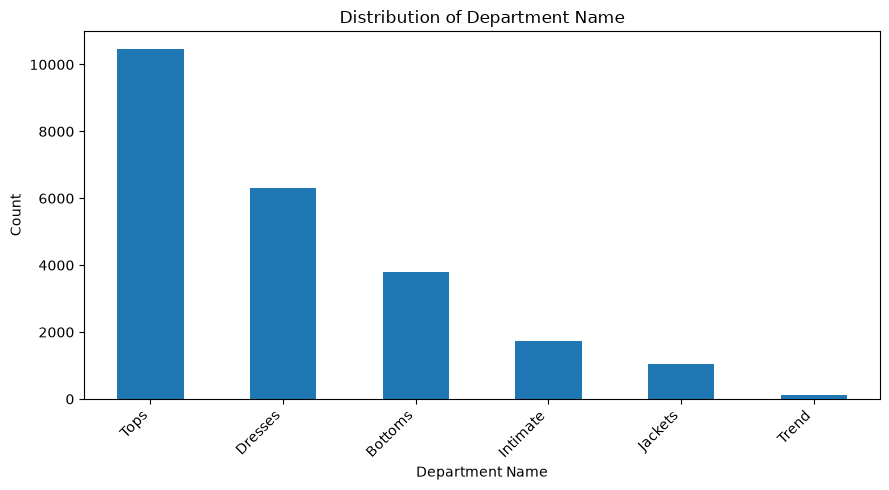

In [19]:
target_counts = ecom_clean[TARGET].value_counts().sort_values(ascending=False)
target_percent = (target_counts / target_counts.sum() * 100).round(2)

display(pd.DataFrame({"count": target_counts, "percent": target_percent}))

plt.figure(figsize=(9, 5))
target_counts.plot(kind="bar")
plt.title("Distribution of Department Name")
plt.xlabel("Department Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## V.2. Phân bố các đặc trưng quan trọng và đặc điểm review


,review_words,review_chars
count,23472.000000,23472.000000
mean,60.849054,314.139485
std,30.882529,156.678720
min,0.000000,0.000000
25%,36.000000,188.000000
50%,60.000000,309.000000
75%,91.000000,470.000000
max,121.000000,557.000000


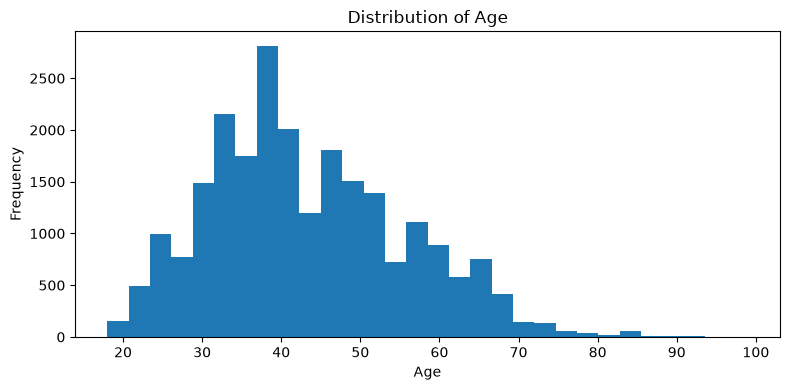

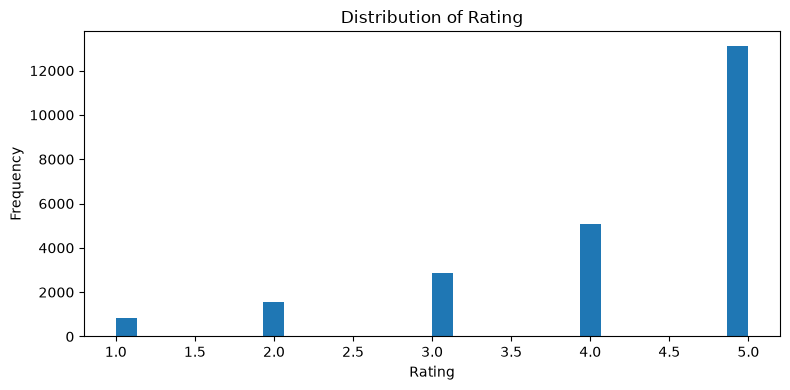

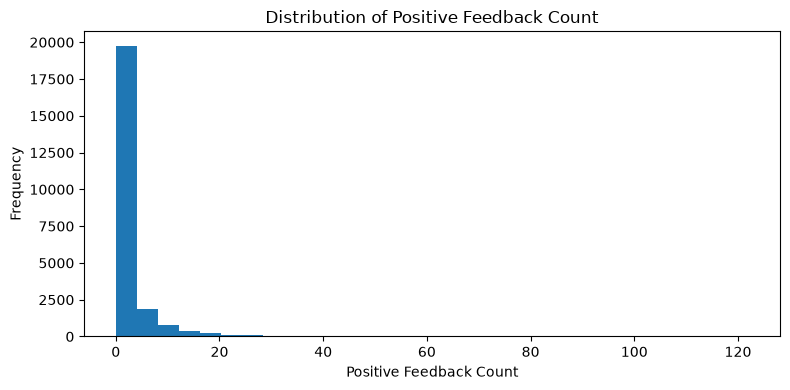

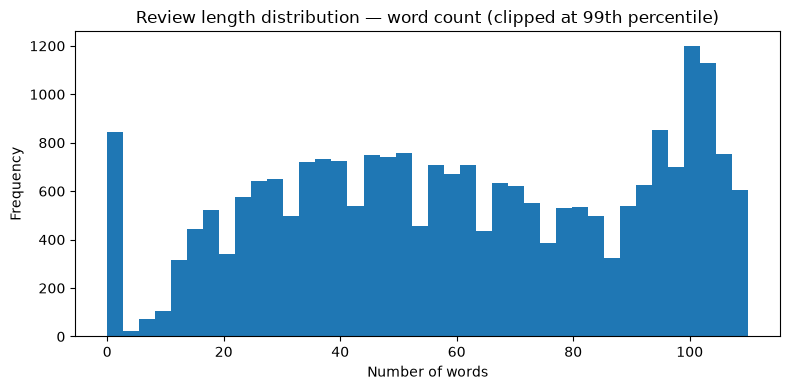

Recommended IND distribution:


,count,percent
Recommended IND,,
1.0,19300,82.23
0.0,4172,17.77


In [20]:
review_words = ecom_clean["Combined Text"].fillna("").astype(str).str.split().str.len()

review_chars = ecom_clean["Combined Text"].fillna("").astype(str).str.len()

review_length_summary = pd.DataFrame(
    {
        "review_words": review_words.describe(),
        "review_chars": review_chars.describe(),
    }
)
display(review_length_summary)

for col in ["Age", "Rating", "Positive Feedback Count"]:
    plt.figure(figsize=(8, 4))
    ecom_clean[col].dropna().plot(kind="hist", bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
review_words.clip(upper=review_words.quantile(0.99)).plot(kind="hist", bins=40)
plt.title("Review length distribution — word count (clipped at 99th percentile)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Recommended IND distribution:")
display(
    pd.DataFrame(
        {
            "count": ecom_clean["Recommended IND"].value_counts(dropna=False),
            "percent": (
                ecom_clean["Recommended IND"]
                .value_counts(normalize=True, dropna=False)
                .mul(100)
                .round(2)
            ),
        }
    )
)


## V.3. Mối quan hệ giữa các đặc trưng và target


,count,age_mean,rating_mean,recommend_rate,positive_feedback_mean,review_words_mean
Department Name,,,,,,
Tops,10468,44.125908,4.172239,0.815151,2.427111,57.917463
Dresses,6319,42.114892,4.150815,0.808197,3.087514,65.796962
Bottoms,3799,43.093182,4.288760,0.851277,2.117136,61.552251
Intimate,1735,41.295677,4.280115,0.850144,1.887608,55.308357
Jackets,1032,43.964147,4.264535,0.836240,2.825581,65.785853
Trend,119,44.058824,3.815126,0.739496,3.369748,71.512605


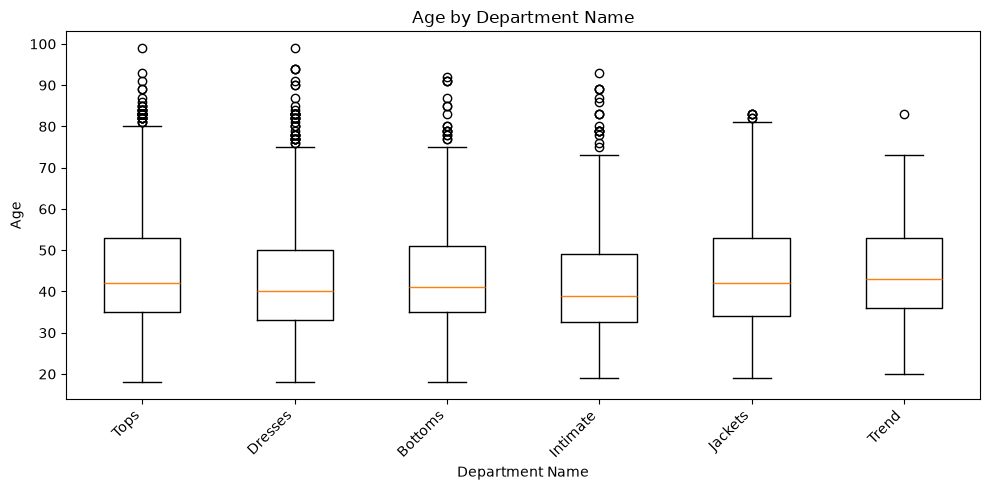

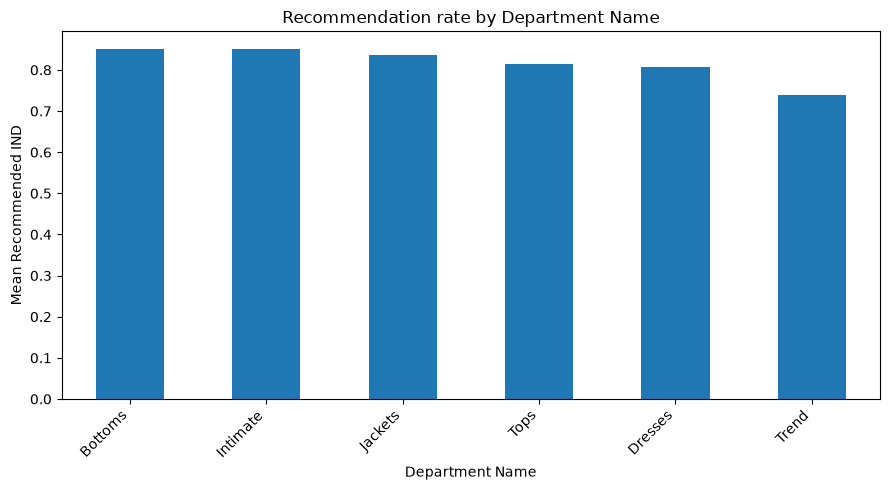

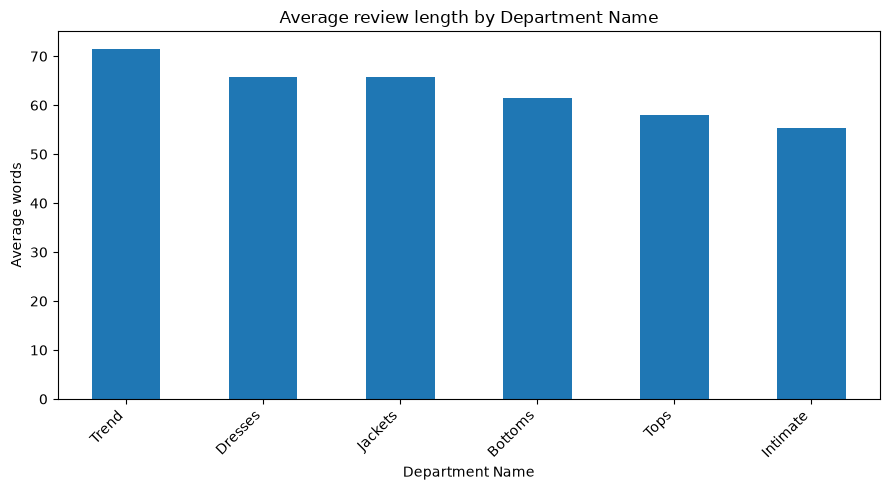

In [21]:
# Mean/median behavior by target
feature_target_summary = (
    ecom_clean.assign(review_words=review_words)
    .groupby(TARGET)
    .agg(
        count=(TARGET, "size"),
        age_mean=("Age", "mean"),
        rating_mean=("Rating", "mean"),
        recommend_rate=("Recommended IND", "mean"),
        positive_feedback_mean=("Positive Feedback Count", "mean"),
        review_words_mean=("review_words", "mean"),
    )
    .sort_values("count", ascending=False)
)

display(feature_target_summary)

# Age by target
age_groups = [
    ecom_clean.loc[ecom_clean[TARGET] == cls, "Age"].dropna().to_numpy()
    for cls in target_counts.index
]
plt.figure(figsize=(10, 5))
plt.boxplot(age_groups, tick_labels=list(target_counts.index))
plt.title("Age by Department Name")
plt.xlabel("Department Name")
plt.ylabel("Age")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Recommendation rate by target
plt.figure(figsize=(9, 5))
feature_target_summary["recommend_rate"].sort_values(ascending=False).plot(kind="bar")
plt.title("Recommendation rate by Department Name")
plt.xlabel("Department Name")
plt.ylabel("Mean Recommended IND")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Review length by target
plt.figure(figsize=(9, 5))
feature_target_summary["review_words_mean"].sort_values(ascending=False).plot(kind="bar")
plt.title("Average review length by Department Name")
plt.xlabel("Department Name")
plt.ylabel("Average words")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## V.4. Phân tích tương quan


,Age,Rating,Recommended IND,Positive Feedback Count
Age,1.000000,0.026967,0.030712,0.043049
Rating,0.026967,1.000000,0.792311,-0.064820
Recommended IND,0.030712,0.792311,1.000000,-0.068954
Positive Feedback Count,0.043049,-0.064820,-0.068954,1.000000


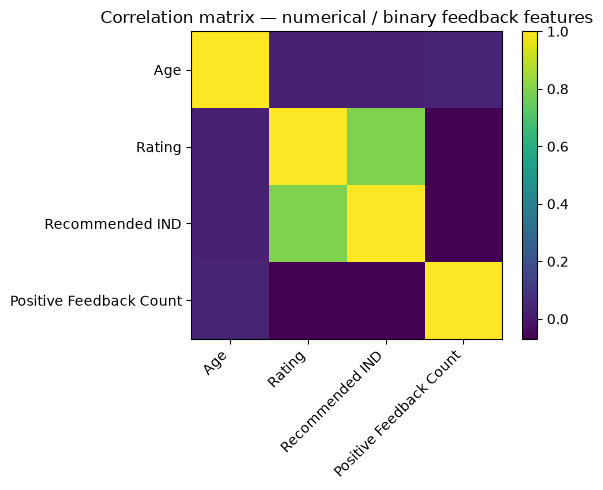

In [22]:
corr_cols = ["Age", "Rating", "Recommended IND", "Positive Feedback Count"]
corr = ecom_clean[corr_cols].corr(numeric_only=True)

display(corr)

plt.figure(figsize=(6, 5))
img = plt.imshow(corr, aspect="auto")
plt.colorbar(img)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix — numerical / binary feedback features")
plt.tight_layout()
plt.show()


## V.5. Product categories / interest frequency



Division Name


,count
Division Name,
General,13850
General Petite,8120
Initmates,1502


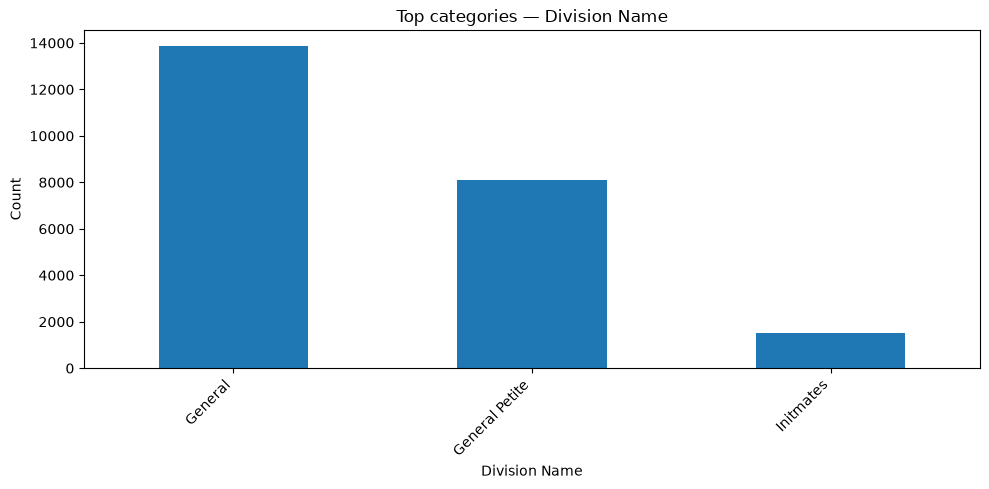


Department Name


,count
Department Name,
Tops,10468
Dresses,6319
Bottoms,3799
Intimate,1735
Jackets,1032
Trend,119


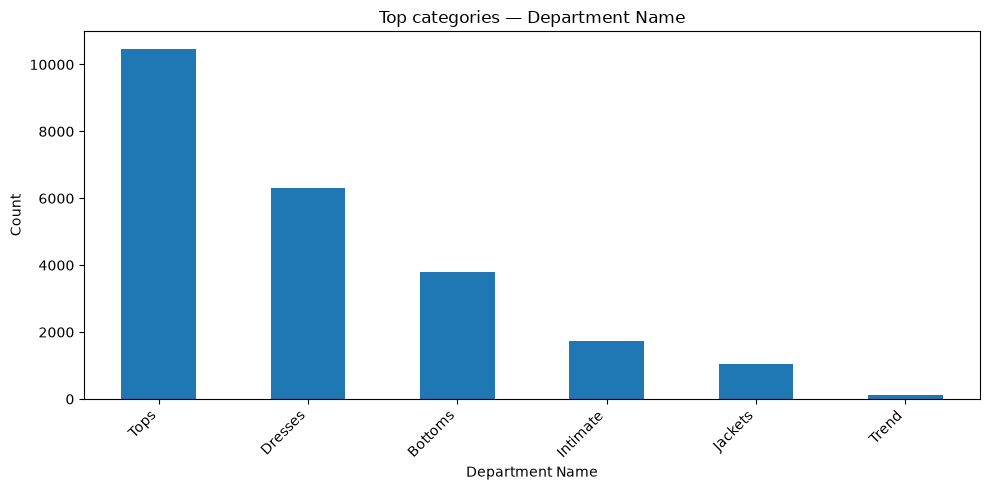


Class Name


,count
Class Name,
Dresses,6319
Knits,4843
Blouses,3097
Sweaters,1428
Pants,1388
Jeans,1147
Fine gauge,1100
Skirts,945
Jackets,704


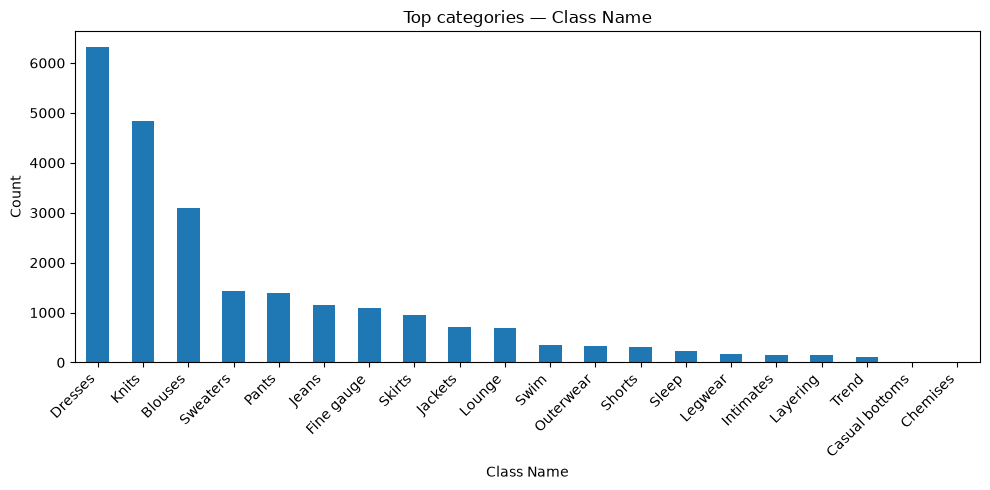

In [23]:
for col in ["Division Name", "Department Name", "Class Name"]:
    counts = ecom_clean[col].value_counts().head(20)
    print(f"\n{col}")
    display(counts.to_frame("count"))

    plt.figure(figsize=(10, 5))
    counts.plot(kind="bar")
    plt.title(f"Top categories — {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## V.6. Frequent terms / keywords


,term,count
0,dress,12221
1,love,10812
2,size,8974
3,fit,7935
4,great,7905
5,like,7386
6,wear,6551
7,just,5830
8,fabric,5081
9,small,5066


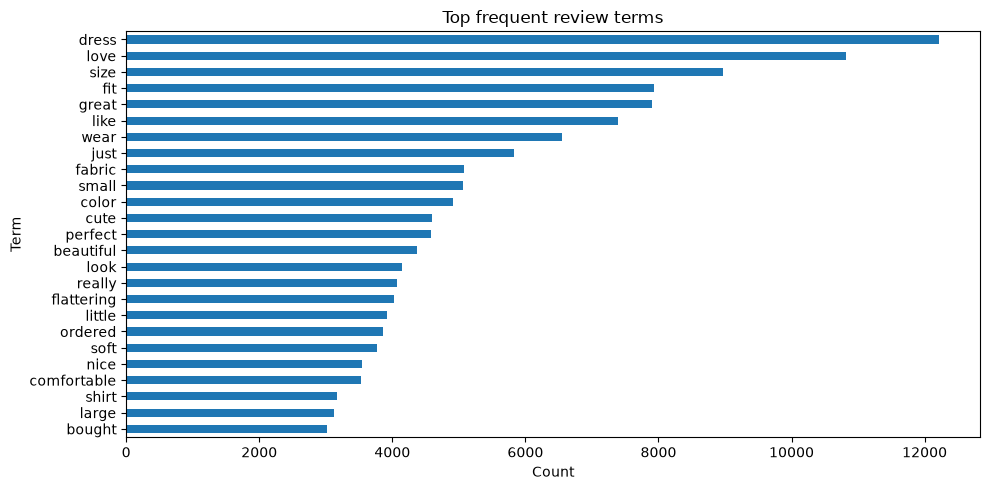

In [24]:
# Keywords chỉ fit trên clean primary data cho EDA.
# Đây là EDA, không phải transformer dùng để train model.
keyword_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=5,
    max_features=2000,
)

keyword_matrix = keyword_vectorizer.fit_transform(ecom_clean["Combined Text"])
term_counts = np.asarray(keyword_matrix.sum(axis=0)).ravel()
terms = keyword_vectorizer.get_feature_names_out()

top_idx = np.argsort(term_counts)[-25:][::-1]
top_keywords = pd.DataFrame(
    {
        "term": terms[top_idx],
        "count": term_counts[top_idx],
    }
)

display(top_keywords)

plt.figure(figsize=(10, 5))
top_keywords.set_index("term")["count"].sort_values().plot(kind="barh")
plt.title("Top frequent review terms")
plt.xlabel("Count")
plt.ylabel("Term")
plt.tight_layout()
plt.show()


### Khung giải thích mỗi trực quan hóa khi đưa vào báo cáo

Với từng figure chính cần viết đủ:
- **Quan sát:** hình cho thấy điều gì?
- **Diễn giải:** điều đó có ý nghĩa gì về dữ liệu/customer interest?
- **Hàm ý đối với ML:** ảnh hưởng đến class imbalance, feature usefulness, preprocessing hoặc model selection như thế nào?

Không nên chỉ chèn hình mà không giải thích.


# VI. Train, Validation, and Test Data

Split sử dụng:

\[
D = D_{train} \cup D_{validation} \cup D_{test}
\]

với tỷ lệ **70% / 15% / 15%** và `stratify` theo `Department Name`.

Test set phải độc lập:
- không dùng để fit imputer;
- không dùng để fit scaler;
- không dùng để học TF-IDF vocabulary / IDF;
- không dùng để chọn hyperparameter/model;
- chỉ dùng **một lần cuối** sau khi model đã được chọn.


In [25]:
split_summary = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Rows": len(X_train),
            "Percent": round(len(X_train) / len(X_all) * 100, 2),
        },
        {
            "Split": "Validation",
            "Rows": len(X_val),
            "Percent": round(len(X_val) / len(X_all) * 100, 2),
        },
        {
            "Split": "Test",
            "Rows": len(X_test),
            "Percent": round(len(X_test) / len(X_all) * 100, 2),
        },
    ]
)
display(split_summary)

print("Class distribution — Train")
display((y_train.value_counts(normalize=True) * 100).round(2).to_frame("%"))

print("Class distribution — Validation")
display((y_val.value_counts(normalize=True) * 100).round(2).to_frame("%"))

print("Class distribution — Test")
display((y_test.value_counts(normalize=True) * 100).round(2).to_frame("%"))

# Chứng minh index độc lập.
print("Train ∩ Validation:", len(set(X_train.index) & set(X_val.index)))
print("Train ∩ Test:", len(set(X_train.index) & set(X_test.index)))
print("Validation ∩ Test:", len(set(X_val.index) & set(X_test.index)))

assert len(set(X_train.index) & set(X_val.index)) == 0
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_val.index) & set(X_test.index)) == 0


,Split,Rows,Percent
0,Train,16430,70.0
1,Validation,3521,15.0
2,Test,3521,15.0


Class distribution — Train


,%
Department Name,
Tops,44.60
Dresses,26.92
Bottoms,16.18
Intimate,7.40
Jackets,4.39
Trend,0.51


Class distribution — Validation


,%
Department Name,
Tops,44.59
Dresses,26.92
Bottoms,16.19
Intimate,7.38
Jackets,4.40
Trend,0.51


Class distribution — Test


,%
Department Name,
Tops,44.59
Dresses,26.92
Bottoms,16.19
Intimate,7.38
Jackets,4.40
Trend,0.51


Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [26]:
print("DATA LEAKAGE CONTROL")
print("- Imputer fitted on train only")
print("- StandardScaler fitted on train only")
print("- TF-IDF vocabulary/IDF fitted on train only")
print("- SVD embedding demo fitted on train text only")
print("- Validation used for model comparison")
print("- Test reserved for final evaluation only")
print("- Division Name / Class Name excluded from model features")


DATA LEAKAGE CONTROL
- Imputer fitted on train only
- StandardScaler fitted on train only
- TF-IDF vocabulary/IDF fitted on train only
- SVD embedding demo fitted on train text only
- Validation used for model comparison
- Test reserved for final evaluation only
- Division Name / Class Name excluded from model features


# VII. Model Development

Assignment yêu cầu so sánh **6 model** cho E-commerce:
1. Logistic Regression;
2. Decision Tree;
3. Random Forest;
4. SVM;
5. text-based linear classifier;
6. một model khác có lý do lựa chọn phù hợp.

Notebook dùng:
- `LogisticRegression`
- `DecisionTreeClassifier`
- `RandomForestClassifier`
- `LinearSVC`
- `SGDClassifier(loss="log_loss")` — text-friendly linear classifier
- `ExtraTreesClassifier` — model thứ sáu, phù hợp dữ liệu sparse/high-dimensional và tạo thêm một ensemble comparison.

Tất cả 6 model trong bảng chính được huấn luyện trên **combined representation** để so sánh thuật toán trên cùng một input.

Ngoài ra, dùng cùng `LogisticRegression` để so sánh:
- tabular-only;
- text-only;
- tabular + text.

Điều này trực tiếp trả lời câu hỏi: **text có cải thiện dự đoán so với tabular-only hay không?**


In [27]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


# TEXT-ONLY representation fit on train.
text_only_vectorizer = TfidfVectorizer(**TEXT_VECTORIZER_PARAMS)
X_train_text = text_only_vectorizer.fit_transform(X_train["Combined Text"])
X_val_text = text_only_vectorizer.transform(X_val["Combined Text"])
X_test_text = text_only_vectorizer.transform(X_test["Combined Text"])

print("Text-only shapes:")
print(X_train_text.shape, X_val_text.shape, X_test_text.shape)


Text-only shapes:
(16430, 8000) (3521, 8000) (3521, 8000)


In [28]:
# ------------------------------------
# Representation comparison
# Same model: Logistic Regression
# ------------------------------------
representation_models = {
    "Tabular-only": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Text-only": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Tabular + Text": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
}

representation_data = {
    "Tabular-only": (X_train_tab, X_val_tab),
    "Text-only": (X_train_text, X_val_text),
    "Tabular + Text": (X_train_comb, X_val_comb),
}

representation_results = []

for rep_name, model in representation_models.items():
    Xtr, Xv = representation_data[rep_name]

    start = time.perf_counter()
    model.fit(Xtr, y_train)
    elapsed = time.perf_counter() - start

    pred = model.predict(Xv)
    metrics = classification_metrics(y_val, pred)

    representation_results.append(
        {
            "Representation": rep_name,
            **metrics,
            "Training_time_s": elapsed,
        }
    )

representation_results_df = (
    pd.DataFrame(representation_results)
    .sort_values("F1_macro", ascending=False)
    .reset_index(drop=True)
)

display(representation_results_df)

tab_f1 = float(
    representation_results_df.loc[
        representation_results_df["Representation"] == "Tabular-only",
        "F1_macro",
    ].iloc[0]
)
text_f1 = float(
    representation_results_df.loc[
        representation_results_df["Representation"] == "Text-only",
        "F1_macro",
    ].iloc[0]
)
comb_f1 = float(
    representation_results_df.loc[
        representation_results_df["Representation"] == "Tabular + Text",
        "F1_macro",
    ].iloc[0]
)

print("Δ F1_macro Combined - Tabular =", comb_f1 - tab_f1)
print("Δ F1_macro Text - Tabular =", text_f1 - tab_f1)


,Representation,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Training_time_s
0,Text-only,0.810281,0.622895,0.648563,0.624863,0.821379,1.102750
1,Tabular + Text,0.811417,0.617965,0.648359,0.624780,0.820948,1.821460
2,Tabular-only,0.151093,0.201282,0.224619,0.130809,0.173132,0.074601


Δ F1_macro Combined - Tabular = 0.49397153888839396
Δ F1_macro Text - Tabular = 0.49405412091959355


In [29]:
# ------------------------------------
# Six required / justified models
# Same combined representation
# ------------------------------------
MODEL_SPECS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=30,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=30,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Text Linear SGD": SGDClassifier(
        loss="log_loss",
        alpha=1e-5,
        max_iter=2000,
        tol=1e-4,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=35,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
}

trained_models = {}
validation_predictions = {}
validation_scores = {}
model_rows = []

for model_name, model in MODEL_SPECS.items():
    print("\n" + "=" * 80)
    print("TRAINING:", model_name)

    start = time.perf_counter()
    model.fit(X_train_comb, y_train)
    training_time = time.perf_counter() - start

    pred = model.predict(X_val_comb)

    metrics = classification_metrics(y_val, pred)

    # ROC-AUC where appropriate.
    roc_auc_value = np.nan
    score_matrix = None

    if hasattr(model, "predict_proba"):
        score_matrix = model.predict_proba(X_val_comb)
        try:
            roc_auc_value = roc_auc_score(
                y_val,
                score_matrix,
                labels=model.classes_,
                multi_class="ovr",
                average="weighted",
            )
        except Exception:
            roc_auc_value = np.nan
    elif hasattr(model, "decision_function"):
        # Dùng raw decision scores cho one-vs-rest ROC plots.
        score_matrix = model.decision_function(X_val_comb)

    trained_models[model_name] = model
    validation_predictions[model_name] = pred
    validation_scores[model_name] = score_matrix

    model_rows.append(
        {
            "Model": model_name,
            "Representation": "Tabular + Text",
            **metrics,
            "ROC_AUC_weighted_OVR": roc_auc_value,
            "Training_time_s": training_time,
        }
    )

validation_results = (
    pd.DataFrame(model_rows).sort_values("F1_macro", ascending=False).reset_index(drop=True)
)

print("\nVALIDATION RESULTS")
display(validation_results)



TRAINING: Logistic Regression

TRAINING: Decision Tree

TRAINING: Random Forest

TRAINING: Linear SVM

TRAINING: Text Linear SGD

TRAINING: Extra Trees

VALIDATION RESULTS


,Model,Representation,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_weighted_OVR,Training_time_s
0,Logistic Regression,Tabular + Text,0.811417,0.617965,0.648359,0.624780,0.820948,0.956564,1.907217
1,Linear SVM,Tabular + Text,0.832718,0.631736,0.614633,0.621789,0.827548,NaN,1.960162
2,Text Linear SGD,Tabular + Text,0.833286,0.634536,0.614713,0.620148,0.826684,0.957766,0.856831
3,Extra Trees,Tabular + Text,0.805453,0.585041,0.602162,0.592103,0.806341,0.943107,1.027181
4,Random Forest,Tabular + Text,0.791536,0.573793,0.581006,0.576901,0.790722,0.940760,1.162845
5,Decision Tree,Tabular + Text,0.686169,0.546691,0.551609,0.531980,0.725254,0.859664,4.874122


# VIII. Model Evaluation

Vì target có 6 lớp và mất cân bằng đáng kể, chỉ `Accuracy` là chưa đủ.

Các metric:
- **Accuracy:** tỷ lệ dự đoán đúng tổng thể.
- **Precision macro:** precision trung bình coi mỗi class có trọng số như nhau.
- **Recall macro:** recall trung bình trên tất cả class.
- **F1 macro:** harmonic mean của precision/recall, mỗi class có trọng số ngang nhau; đây là **metric chính để chọn model**.
- **F1 weighted:** phản ánh hiệu năng có xét số sample của từng class.
- **ROC-AUC OVR:** báo cáo khi model cung cấp score/probability phù hợp.
- **Confusion Matrix:** phải được diễn giải, không chỉ hiển thị.

`F1_macro` được ưu tiên vì các department nhỏ như `Trend` có thể bị che khuất nếu chỉ tối ưu accuracy.


## VIII.1. Kết quả validation


In [30]:
display(
    validation_results[
        [
            "Model",
            "Accuracy",
            "Precision_macro",
            "Recall_macro",
            "F1_macro",
            "F1_weighted",
            "ROC_AUC_weighted_OVR",
            "Training_time_s",
        ]
    ]
)

best_model_name = validation_results.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_val_pred = validation_predictions[best_model_name]

print("BEST MODEL BY VALIDATION F1_macro:", best_model_name)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_weighted_OVR,Training_time_s
0,Logistic Regression,0.811417,0.617965,0.648359,0.624780,0.820948,0.956564,1.907217
1,Linear SVM,0.832718,0.631736,0.614633,0.621789,0.827548,NaN,1.960162
2,Text Linear SGD,0.833286,0.634536,0.614713,0.620148,0.826684,0.957766,0.856831
3,Extra Trees,0.805453,0.585041,0.602162,0.592103,0.806341,0.943107,1.027181
4,Random Forest,0.791536,0.573793,0.581006,0.576901,0.790722,0.940760,1.162845
5,Decision Tree,0.686169,0.546691,0.551609,0.531980,0.725254,0.859664,4.874122


BEST MODEL BY VALIDATION F1_macro: Logistic Regression


## VIII.2. Confusion Matrix và Classification Report


RAW CONFUSION MATRIX


,Bottoms,Dresses,Intimate,Jackets,Tops,Trend
Bottoms,461,13,63,4,28,1
Dresses,23,807,54,5,55,4
Intimate,20,27,145,15,52,1
Jackets,1,3,9,120,20,2
Tops,23,24,132,68,1323,0
Trend,4,9,1,1,2,1


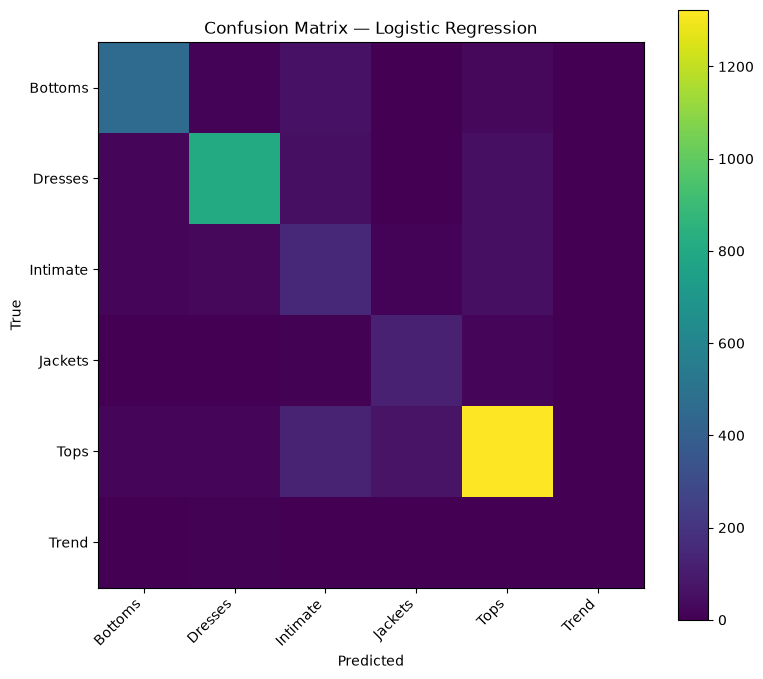

NORMALIZED CONFUSION MATRIX


,Bottoms,Dresses,Intimate,Jackets,Tops,Trend
Bottoms,0.809,0.023,0.111,0.007,0.049,0.002
Dresses,0.024,0.851,0.057,0.005,0.058,0.004
Intimate,0.077,0.104,0.558,0.058,0.200,0.004
Jackets,0.006,0.019,0.058,0.774,0.129,0.013
Tops,0.015,0.015,0.084,0.043,0.843,0.000
Trend,0.222,0.500,0.056,0.056,0.111,0.056


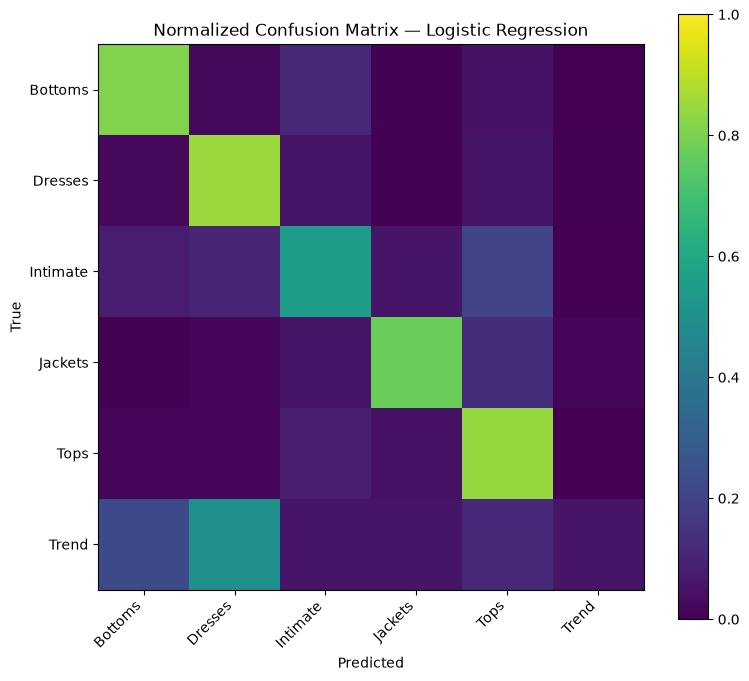

CLASSIFICATION REPORT


,precision,recall,f1-score,support
Bottoms,0.866541,0.808772,0.836661,570.000000
Dresses,0.913930,0.851266,0.881486,948.000000
Intimate,0.358911,0.557692,0.436747,260.000000
Jackets,0.563380,0.774194,0.652174,155.000000
Tops,0.893919,0.842675,0.867541,1570.000000
Trend,0.111111,0.055556,0.074074,18.000000
accuracy,0.811417,0.811417,0.811417,0.811417
macro avg,0.617965,0.648359,0.624780,3521.000000
weighted avg,0.836816,0.811417,0.820948,3521.000000


In [31]:
classes = np.array(sorted(y_train.unique()))

cm = confusion_matrix(y_val, best_val_pred, labels=classes)
cm_norm = confusion_matrix(
    y_val,
    best_val_pred,
    labels=classes,
    normalize="true",
)

print("RAW CONFUSION MATRIX")
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
display(cm_df)

plt.figure(figsize=(8, 7))
img = plt.imshow(cm)
plt.colorbar(img)
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print("NORMALIZED CONFUSION MATRIX")
display(pd.DataFrame(cm_norm, index=classes, columns=classes).round(3))

plt.figure(figsize=(8, 7))
img = plt.imshow(cm_norm, vmin=0, vmax=1)
plt.colorbar(img)
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Normalized Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print("CLASSIFICATION REPORT")
report = classification_report(
    y_val,
    best_val_pred,
    labels=classes,
    output_dict=True,
    zero_division=0,
)
display(pd.DataFrame(report).T)


## VIII.3. ROC-AUC / One-vs-Rest ROC khi phù hợp


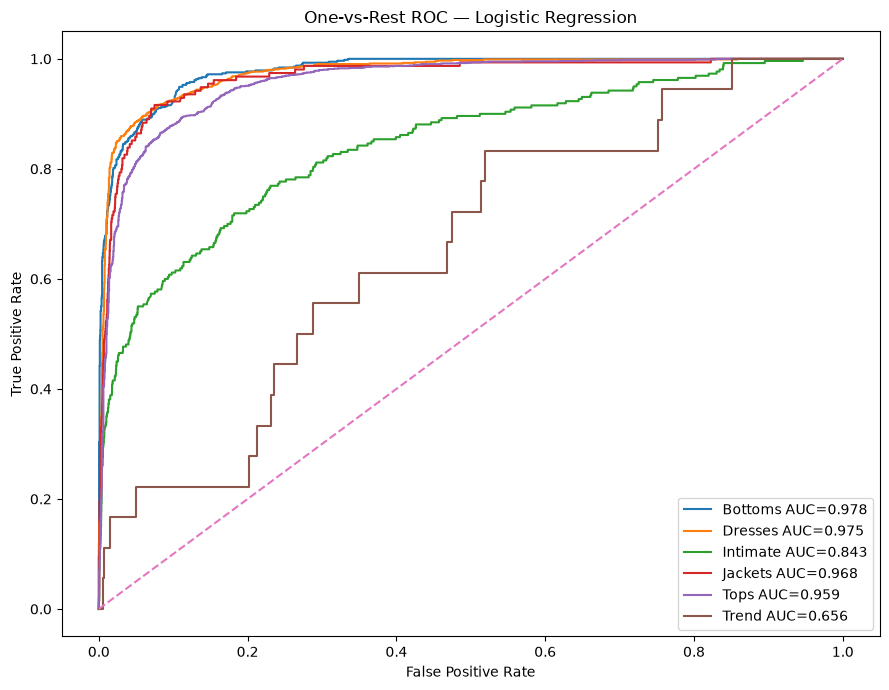

,Class,ROC_AUC_OVR
0,Bottoms,0.978312
1,Dresses,0.974955
2,Intimate,0.842772
3,Jackets,0.967535
4,Tops,0.958775
5,Trend,0.655724


In [32]:
# ROC per class dùng probability hoặc decision score.
score_matrix = validation_scores[best_model_name]

if score_matrix is None:
    print("Model không cung cấp probability/decision score -> bỏ ROC-AUC.")
else:
    y_val_bin = label_binarize(y_val, classes=classes)

    # Căn chỉnh cột score theo model.classes_
    model_classes = np.array(best_model.classes_)

    if score_matrix.ndim == 1:
        print("Binary-style score không phù hợp multiclass plot.")
    else:
        class_auc_rows = []

        plt.figure(figsize=(9, 7))

        for class_idx, cls in enumerate(classes):
            model_col = int(np.where(model_classes == cls)[0][0])
            class_scores = score_matrix[:, model_col]

            fpr, tpr, _ = roc_curve(y_val_bin[:, class_idx], class_scores)
            class_auc = auc(fpr, tpr)

            class_auc_rows.append(
                {
                    "Class": cls,
                    "ROC_AUC_OVR": class_auc,
                }
            )

            plt.plot(fpr, tpr, label=f"{cls} AUC={class_auc:.3f}")

        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"One-vs-Rest ROC — {best_model_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        display(pd.DataFrame(class_auc_rows))


## VIII.4. Error Analysis


In [33]:
error_mask = best_val_pred != y_val.to_numpy()

error_df = X_val.loc[error_mask, MODEL_FEATURES].copy()
error_df["True Department"] = y_val.to_numpy()[error_mask]
error_df["Predicted Department"] = best_val_pred[error_mask]

# Confidence/proxy score
if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(X_val_comb)
    confidence = proba.max(axis=1)
elif hasattr(best_model, "decision_function"):
    decision = best_model.decision_function(X_val_comb)
    if decision.ndim == 1:
        confidence = np.abs(decision)
    else:
        shifted = decision - decision.max(axis=1, keepdims=True)
        softmax_proxy = np.exp(shifted)
        softmax_proxy /= softmax_proxy.sum(axis=1, keepdims=True)
        confidence = softmax_proxy.max(axis=1)
else:
    confidence = np.full(len(X_val), np.nan)

error_df["Confidence / score proxy"] = confidence[error_mask]
error_df["Text preview"] = error_df["Combined Text"].astype(str).str.slice(0, 300)

display(
    error_df[
        [
            "True Department",
            "Predicted Department",
            "Confidence / score proxy",
            "Age",
            "Rating",
            "Recommended IND",
            "Text preview",
        ]
    ]
    .sort_values("Confidence / score proxy", ascending=False)
    .head(25)
)

print("Number of validation errors:", int(error_mask.sum()))
print("Validation error rate (%):", round(error_mask.mean() * 100, 2))


,True Department,Predicted Department,Confidence / score proxy,Age,Rating,Recommended IND,Text preview
15048,Tops,Jackets,0.975968,34.0,5.0,1.0,Perfect for cooler weather Completely versatile and absolutely perfect for days when my pea coat is too heavy. looks amazing with jeans ...
1019,Tops,Jackets,0.964124,42.0,5.0,1.0,Beautiful coat Love this coat - great fall piece! i bought the green color and it looks as shown in the picture. great retailer purchase!
16370,Dresses,Intimate,0.950840,64.0,5.0,1.0,I ordered this in the red stripe material. i love it! it is so soft and easy to wear. i'm wearing it as a bathing suit cover. a nice pin...
21782,Intimate,Tops,0.940529,27.0,5.0,1.0,Love this shirt and the details on the collar.
19960,Trend,Dresses,0.936623,53.0,5.0,1.0,Beautiful dress This dress is so beautiful! i ordered it online and when i received it i was so pleased with how it was even better in p...
14013,Tops,Jackets,0.935091,68.0,5.0,1.0,"My new favorite jacket I love this jacket and always get compliments when i wear it. i have the green version, and the color is lovely. ..."
10159,Tops,Intimate,0.928793,62.0,5.0,1.0,Love this tunic! Really cute over my white cropped pilcro jeans. or as a beach cover up over a bathing suit. i want this in more colors!
16663,Trend,Bottoms,0.927562,59.0,4.0,1.0,"This skirt is adorable. i like it because its different and i like this length. the cactus look gray in the picture, but they are green."
4473,Intimate,Dresses,0.924164,36.0,3.0,0.0,"I really thought i would love this dress the style is really nice and the material is great. however, the length made me feel like i loo..."
11986,Intimate,Dresses,0.922477,72.0,4.0,1.0,"Beautiful fall color I am somewhere between a size 6 or 8, so i ordered this dress in a size small. mistake. too small. the color of thi..."


Number of validation errors: 664
Validation error rate (%): 18.86


## VIII.5. Văn bản có cải thiện dự đoán không?

Kết luận phải dựa trên bảng `representation_results_df`, không được suy đoán.

- Nếu `Tabular + Text` có `F1_macro` cao hơn `Tabular-only`, text bổ sung tín hiệu ngữ nghĩa hữu ích cho category-interest prediction.
- Nếu không cải thiện, cần thảo luận khả năng TF-IDF chưa đủ biểu diễn ngữ cảnh, text gây noise, hoặc tabular signals đã mạnh.

### Business interpretation

Target `Department Name` đại diện cho nhóm interest ở mức department. Prediction có thể hỗ trợ:
- personalized product/category recommendations;
- routing khách hàng tới nhóm sản phẩm phù hợp;
- targeted promotions theo nhóm category;
- phân loại review phục vụ search/catalog analytics.

Không diễn giải output như “purchase probability”, vì dataset không chứa lịch sử purchase/cart thực tế.


# IX. Model Comparison

Assignment yêu cầu bảng so sánh và giải thích model cuối cùng được chọn.

Tiêu chí chính:
1. `F1_macro` trên validation;
2. Accuracy / weighted F1;
3. khả năng xử lý class thiểu số;
4. computational cost;
5. khả năng persistence/deployment.

Sau khi model được chọn bằng validation, **train + validation** được gộp để refit final pipeline.  
Test set chỉ được đánh giá một lần ở cuối.


In [34]:
model_comparison_table = validation_results[
    [
        "Model",
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "F1_weighted",
        "ROC_AUC_weighted_OVR",
        "Training_time_s",
    ]
].copy()

display(model_comparison_table)

selected_model_name = model_comparison_table.iloc[0]["Model"]
selected_model_template = clone(MODEL_SPECS[selected_model_name])

print("SELECTED FINAL MODEL:", selected_model_name)
print("Selection metric: validation F1_macro")
display(model_comparison_table.head(1))


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_weighted_OVR,Training_time_s
0,Logistic Regression,0.811417,0.617965,0.648359,0.624780,0.820948,0.956564,1.907217
1,Linear SVM,0.832718,0.631736,0.614633,0.621789,0.827548,NaN,1.960162
2,Text Linear SGD,0.833286,0.634536,0.614713,0.620148,0.826684,0.957766,0.856831
3,Extra Trees,0.805453,0.585041,0.602162,0.592103,0.806341,0.943107,1.027181
4,Random Forest,0.791536,0.573793,0.581006,0.576901,0.790722,0.940760,1.162845
5,Decision Tree,0.686169,0.546691,0.551609,0.531980,0.725254,0.859664,4.874122


SELECTED FINAL MODEL: Logistic Regression
Selection metric: validation F1_macro


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_weighted_OVR,Training_time_s
0,Logistic Regression,0.811417,0.617965,0.648359,0.62478,0.820948,0.956564,1.907217


In [35]:
# Final refit trên Train + Validation.
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

FINAL_PREPROCESSOR = clone(COMBINED_PREPROCESSOR)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", FINAL_PREPROCESSOR),
        ("model", selected_model_template),
    ]
)

start = time.perf_counter()
final_pipeline.fit(X_trainval, y_trainval)
final_training_time = time.perf_counter() - start

# Test được dùng sau khi selection đã kết thúc.
final_test_pred = final_pipeline.predict(X_test)
final_test_metrics = classification_metrics(y_test, final_test_pred)

# ROC-AUC final where available
final_test_auc = np.nan
final_model_fitted = final_pipeline.named_steps["model"]

if hasattr(final_model_fitted, "predict_proba"):
    final_test_proba = final_pipeline.predict_proba(X_test)
    try:
        final_test_auc = roc_auc_score(
            y_test,
            final_test_proba,
            labels=final_model_fitted.classes_,
            multi_class="ovr",
            average="weighted",
        )
    except Exception:
        final_test_auc = np.nan

final_test_result = pd.DataFrame(
    [
        {
            "Model": selected_model_name,
            **final_test_metrics,
            "ROC_AUC_weighted_OVR": final_test_auc,
            "Refit_time_s": final_training_time,
        }
    ]
)

print("FINAL TEST RESULT")
display(final_test_result)

print("\nFINAL TEST CLASSIFICATION REPORT")
display(
    pd.DataFrame(
        classification_report(
            y_test,
            final_test_pred,
            labels=np.array(sorted(y_trainval.unique())),
            output_dict=True,
            zero_division=0,
        )
    ).T
)


FINAL TEST RESULT


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC_AUC_weighted_OVR,Refit_time_s
0,Logistic Regression,0.829594,0.617816,0.661214,0.633894,0.837871,0.964438,4.311258



FINAL TEST CLASSIFICATION REPORT


,precision,recall,f1-score,support
Bottoms,0.877876,0.870175,0.874009,570.000000
Dresses,0.924528,0.878692,0.901028,948.000000
Intimate,0.380829,0.565385,0.455108,260.000000
Jackets,0.614634,0.812903,0.700000,155.000000
Tops,0.909028,0.840127,0.873221,1570.000000
Trend,0.000000,0.000000,0.000000,18.000000
accuracy,0.829594,0.829594,0.829594,0.829594
macro avg,0.617816,0.661214,0.633894,3521.000000
weighted avg,0.851548,0.829594,0.837871,3521.000000


,Bottoms,Dresses,Intimate,Jackets,Tops,Trend
Bottoms,496,11,45,3,13,2
Dresses,18,833,33,10,49,5
Intimate,28,26,147,12,47,0
Jackets,1,6,4,126,17,1
Tops,17,20,156,53,1319,5
Trend,5,5,1,1,6,0


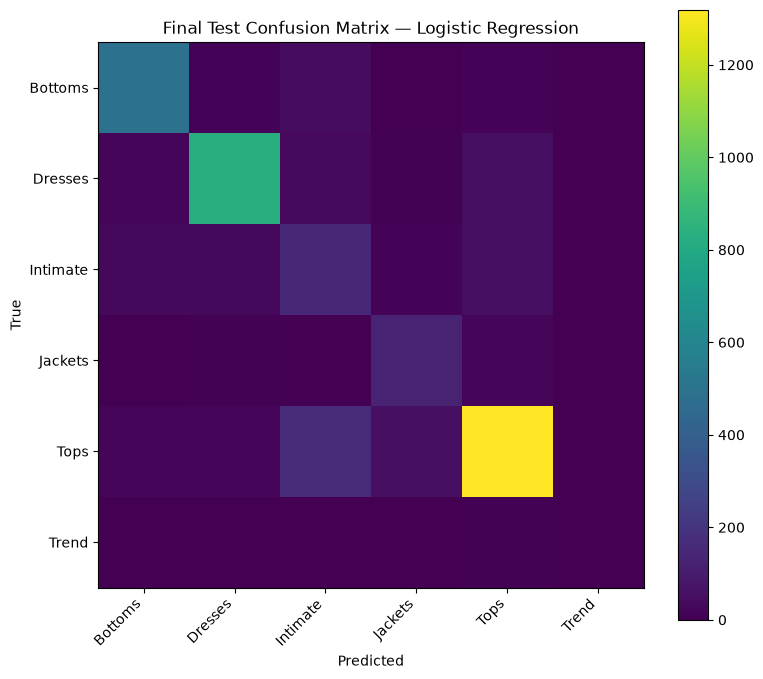

In [36]:
# Final test confusion matrix
final_classes = np.array(sorted(y_trainval.unique()))
final_cm = confusion_matrix(
    y_test,
    final_test_pred,
    labels=final_classes,
)

display(pd.DataFrame(final_cm, index=final_classes, columns=final_classes))

plt.figure(figsize=(8, 7))
img = plt.imshow(final_cm)
plt.colorbar(img)
plt.xticks(range(len(final_classes)), final_classes, rotation=45, ha="right")
plt.yticks(range(len(final_classes)), final_classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Final Test Confusion Matrix — {selected_model_name}")
plt.tight_layout()
plt.show()


# X. Model Persistence

Phải lưu:
- preprocessing;
- feature transformation;
- trained model;
- model configuration/metadata.

Artifact ưu tiên cho deployment là **toàn bộ pipeline** vì nó đảm bảo inference dùng đúng:
- median imputation;
- StandardScaler;
- binary handling;
- TF-IDF vocabulary + IDF;
- final trained classifier.

API **không được fit lại** imputer/scaler/vectorizer trên request mới.


In [37]:
PIPELINE_PATH = ARTIFACT_DIR / "ecommerce_interest_pipeline.joblib"
PREPROCESSOR_PATH = ARTIFACT_DIR / "ecommerce_interest_preprocessor.joblib"
MODEL_PATH = ARTIFACT_DIR / "ecommerce_interest_model.joblib"
METADATA_PATH = ARTIFACT_DIR / "ecommerce_interest_metadata.json"

# Transform final test để lấy exact final feature dimension.
final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_model = final_pipeline.named_steps["model"]

X_test_final_num = final_preprocessor.transform(X_test)
final_feature_names = final_preprocessor.get_feature_names_out()

metadata = {
    "application": "E-commerce Customer Behavior / Interest Discovery",
    "dataset": "Women's Clothing E-Commerce Reviews",
    "kaggle_url": KAGGLE_URL,
    "target": TARGET,
    "task_type": "multiclass_classification",
    "random_seed": RANDOM_SEED,
    "raw_shape": list(primary_raw.shape),
    "clean_shape": list(ecom_clean.shape),
    "model_features": MODEL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "binary_features": BINARY_FEATURES,
    "text_source_columns": TEXT_SOURCE_COLUMNS,
    "text_feature": "Combined Text",
    "excluded_columns": DROPPED_FROM_MODEL,
    "selected_model": selected_model_name,
    "classes": [str(x) for x in final_model.classes_],
    "train_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "final_trainval_rows": len(X_trainval),
    "final_feature_dimension": int(X_test_final_num.shape[1]),
    "final_test_input_shape": list(X_test_final_num.shape),
    "text_vectorizer": TEXT_VECTORIZER_PARAMS,
    "final_test_metrics": {key: float(value) for key, value in final_test_metrics.items()},
    "final_test_roc_auc_weighted_ovr": (None if pd.isna(final_test_auc) else float(final_test_auc)),
}

joblib.dump(final_pipeline, PIPELINE_PATH)
joblib.dump(final_preprocessor, PREPROCESSOR_PATH)
joblib.dump(final_model, MODEL_PATH)

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

artifact_table = pd.DataFrame(
    [
        {
            "Artifact": PIPELINE_PATH.name,
            "Purpose": "Full preprocessing + text representation + trained model",
            "Exists": PIPELINE_PATH.exists(),
        },
        {
            "Artifact": PREPROCESSOR_PATH.name,
            "Purpose": "Imputation + scaling + TF-IDF feature transformation",
            "Exists": PREPROCESSOR_PATH.exists(),
        },
        {
            "Artifact": MODEL_PATH.name,
            "Purpose": "Final trained classifier",
            "Exists": MODEL_PATH.exists(),
        },
        {
            "Artifact": METADATA_PATH.name,
            "Purpose": "Schema, model config, classes, dimensions, metrics",
            "Exists": METADATA_PATH.exists(),
        },
    ]
)

display(artifact_table)

print("Final model-input shape:", X_test_final_num.shape)
print("Final feature dimension d:", X_test_final_num.shape[1])
print("Final numerical dtype:", X_test_final_num.dtype)


,Artifact,Purpose,Exists
0,ecommerce_interest_pipeline.joblib,Full preprocessing + text representation + trained model,True
1,ecommerce_interest_preprocessor.joblib,Imputation + scaling + TF-IDF feature transformation,True
2,ecommerce_interest_model.joblib,Final trained classifier,True
3,ecommerce_interest_metadata.json,"Schema, model config, classes, dimensions, metrics",True


Final model-input shape: (3521, 8004)
Final feature dimension d: 8004
Final numerical dtype: float64


In [38]:
# Reload + inference consistency
reloaded_pipeline = joblib.load(PIPELINE_PATH)

sample_input = X_test.head(5).copy()

pred_before = final_pipeline.predict(sample_input)
pred_after = reloaded_pipeline.predict(sample_input)

reload_check = pd.DataFrame(
    {
        "Prediction before save": pred_before,
        "Prediction after reload": pred_after,
        "Equal": pred_before == pred_after,
    },
    index=sample_input.index,
)

display(sample_input)
display(reload_check)

print("All predictions identical:", bool(np.array_equal(pred_before, pred_after)))
assert np.array_equal(pred_before, pred_after)


,Age,Rating,Positive Feedback Count,Recommended IND,Combined Text
15165,54.0,3.0,0.0,0.0,Cute but..... There were no reviews when i ordered this tunic so nothing to help gauge fit. it is very cute but the fit is strange - ver...
14774,39.0,3.0,2.0,0.0,Cute but very tight These run small. i normally wear 28 on ag stevie's and paige jeans so i ordered these in 28 and they were very tight...
3907,39.0,4.0,0.0,1.0,Great dress I have this in black and red. it's a great and flattering dress that is a worn a bit large. you can wear it out on a date or...
6930,41.0,4.0,0.0,1.0,"Unique white top Although it kind of ran big and the material is stiff causing some protrusion off my shoulders, i decided to keep it on..."
1422,29.0,5.0,0.0,1.0,Comfort This dress is super comfortable and the material is so soft. the fit is very flattering and will cover any imperfections if you ...


,Prediction before save,Prediction after reload,Equal
15165,Tops,Tops,True
14774,Bottoms,Bottoms,True
3907,Dresses,Dresses,True
6930,Tops,Tops,True
1422,Dresses,Dresses,True


All predictions identical: True


In [39]:
# Input schema dùng cho API/inference sau này.
inference_schema = pd.DataFrame(
    [
        {
            "Field": "Age",
            "Type": "number",
            "Required": True,
            "Validation": "0 < Age <= 100",
        },
        {
            "Field": "Rating",
            "Type": "integer",
            "Required": True,
            "Validation": "1..5",
        },
        {
            "Field": "Recommended IND",
            "Type": "integer/binary",
            "Required": True,
            "Validation": "0 or 1",
        },
        {
            "Field": "Positive Feedback Count",
            "Type": "number",
            "Required": True,
            "Validation": ">= 0",
        },
        {
            "Field": "Combined Text",
            "Type": "string",
            "Required": True,
            "Validation": "customer review/title text; can be empty but text is preferred",
        },
    ]
)

display(inference_schema)

example_request = X_test.head(1).copy()
print("EXAMPLE RAW INPUT FOR INFERENCE")
display(example_request)

print(
    "\nDeployment rule: load ecommerce_interest_pipeline.joblib and call "
    "pipeline.predict(raw_dataframe). NEVER refit preprocessing on user input."
)


,Field,Type,Required,Validation
0,Age,number,True,0 < Age <= 100
1,Rating,integer,True,1..5
2,Recommended IND,integer/binary,True,0 or 1
3,Positive Feedback Count,number,True,>= 0
4,Combined Text,string,True,customer review/title text; can be empty but text is preferred


EXAMPLE RAW INPUT FOR INFERENCE


,Age,Rating,Positive Feedback Count,Recommended IND,Combined Text
15165,54.0,3.0,0.0,0.0,Cute but..... There were no reviews when i ordered this tunic so nothing to help gauge fit. it is very cute but the fit is strange - ver...



Deployment rule: load ecommerce_interest_pipeline.joblib and call pipeline.predict(raw_dataframe). NEVER refit preprocessing on user input.


# Hoàn tất G.I → G.X

Sau khi `Run All` thành công và **Save notebook**, file này sẽ có đủ output để hoàn thiện báo cáo:

- **G.I** Dataset and Problem Definition
- **G.II** Data Inspection and Understanding
- **G.III** Data Cleaning
- **G.IV** Data Representation
  - Tabular
  - Categorical
  - Text
  - Raw → Clean → Numerical → Model input
  - matrix/vector/token-ID/embedding evidence
- **G.V** EDA
- **G.VI** Train / Validation / Test + data leakage control
- **G.VII** 6 models + tabular-vs-text comparison
- **G.VIII** Metrics + Confusion Matrix + ROC + Error Analysis + Business Interpretation
- **G.IX** Model Comparison + Final Model Selection + Final Test
- **G.X** Model Persistence + Reload/Inference Consistency

### Khi gửi lại notebook

Hãy gửi **file `.ipynb` đã Save với toàn bộ output**, không cần gửi screenshot thủ công.  
Từ output đó có thể viết tài liệu G.I → G.X bằng số liệu thật, không phải giả định.
